In [1]:
# [Cell 1] — Notebook overview, imports, device setup, global config, and cache paths
# -----------------------------------------------------------------------------
# PURPOSE
# This notebook is a turbulence-gravity-cooling specific refactor for The Well.
#
# It replaces the old anonymous "6-channel tensor" treatment with a physically
# named field interface:
#   0 density
#   1 pressure
#   2 temperature
#   3 velocity_x
#   4 velocity_y
#   5 velocity_z
#
# DESIGN GOALS
# ------------
# 1. Keep the workflow scientifically interpretable.
# 2. Provide source-style field trajectory visualizations.
# 3. Build agent-facing summaries from real field semantics.
# 4. Support practical one-step forecasting and lightweight rollouts.
# 5. Keep everything notebook-friendly and debuggable.
# 6. Persist expensive streamed results across notebook restarts.
# -----------------------------------------------------------------------------

import os
import gc
import math
import json
import time
import random
import warnings
import hashlib
from copy import deepcopy
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Reproducibility and device
# -----------------------------------------------------------------------------
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)

print(f"[BOOT] device={DEVICE}, seed={SEED}")

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
DATA_ROOT = Path("./data")
RAW_H5_ROOT = DATA_ROOT / "train"
META_YAML_PATH = None

RUN_DIR = Path("/home/b/bl/bluetopazzz/HybridNets/notebooks")
PLOTS_DIR = RUN_DIR / "plots"
LOG_DIR = RUN_DIR / "logs"
CACHE_DIR = RUN_DIR / "cache"
STREAM_CACHE_DIR = CACHE_DIR / "streamed"
BATCH_CACHE_DIR = CACHE_DIR / "batches"
DATASET_CACHE_DIR = CACHE_DIR / "dataset"

RUN_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
LOG_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True, parents=True)
STREAM_CACHE_DIR.mkdir(exist_ok=True, parents=True)
BATCH_CACHE_DIR.mkdir(exist_ok=True, parents=True)
DATASET_CACHE_DIR.mkdir(exist_ok=True, parents=True)

# -----------------------------------------------------------------------------
# Training / debug config
# -----------------------------------------------------------------------------
BATCH_SIZE = 2
NUM_WORKERS = 0
PIN_MEMORY = False

FAST_MODE = True
EPOCHS_FAST = 1000
EPOCHS_FULL = 10000
LR = 1e-3
PRINT_EVERY = 1

# volume crop to make early experiments feasible
USE_RANDOM_CROP = True
CROP_SIZE = 32

# cache controls
CACHE_FIRST_BATCH = True
CACHE_SAMPLE0 = True
CACHE_CANONICAL_DATASET = True
CANONICAL_DATASET_SIZE = 24 if FAST_MODE else 64   # small persisted subset for training/debug
FORCE_REBUILD_CANONICAL_DATASET = False            # set True only when you want to refresh cache

# fields
FIELD_NAMES = [
    "density",
    "pressure",
    "temperature",
    "velocity_x",
    "velocity_y",
    "velocity_z",
]

SCALAR_FIELD_NAMES = ["density", "pressure", "temperature"]
VECTOR_FIELD_NAMES = ["velocity_x", "velocity_y", "velocity_z"]

FIELD_TO_INDEX = {name: i for i, name in enumerate(FIELD_NAMES)}

DEFAULT_TARGET_FIELDS = FIELD_NAMES[:]

[BOOT] device=cuda, seed=1337


In [2]:
# [Cell 2] — Robust metadata discovery and schema confirmation
# -----------------------------------------------------------------------------

import os
from pathlib import Path
import yaml
import json
from IPython.display import display, Markdown

def find_metadata_yaml(
    filename: str = "turbulence_gravity_cooling.yaml",
    search_roots=None,
) -> Path:
    if search_roots is None:
        search_roots = [
            Path.cwd(),
            Path.cwd() / "data",
            Path.cwd() / "datasets",
            Path.cwd() / "metadata",
            Path.cwd() / "notebooks",
            Path.cwd().parent,
            Path.cwd().parent / "data",
            Path.cwd().parent / "datasets",
            Path.cwd().parent / "metadata",
            Path.cwd().parent / "notebooks",
        ]

    checked = []

    for root in search_roots:
        candidate = root / filename
        checked.append(str(candidate))
        if candidate.exists():
            return candidate.resolve()

    recursive_roots = []
    for root in search_roots:
        if root.exists() and root.is_dir():
            recursive_roots.append(root)

    for root in recursive_roots:
        for candidate in root.rglob(filename):
            return candidate.resolve()

    msg = (
        f"Could not find metadata file: {filename}\n\n"
        f"Current working directory:\n  {Path.cwd()}\n\n"
        f"Checked direct locations:\n  - " + "\n  - ".join(checked) + "\n\n"
        f"Tip:\n"
        f"  Move the YAML into your project root, data/, metadata/, or notebooks/,\n"
        f"  or set META_YAML_PATH manually to the absolute path."
    )
    raise FileNotFoundError(msg)

META_YAML_PATH = find_metadata_yaml("turbulence_gravity_cooling.yaml")
print(f"[FOUND META YAML] {META_YAML_PATH}")

with open(META_YAML_PATH, "r") as f:
    META = yaml.safe_load(f)

display(Markdown("## Confirmed dataset metadata"))
print(json.dumps(META, indent=2))

assert META["dataset_name"] == "turbulence_gravity_cooling"
assert META["n_spatial_dims"] == 3
assert META["spatial_resolution"] == [64, 64, 64]
assert META["field_names"][0] == ["density", "pressure", "temperature"]
assert META["field_names"][1] == ["velocity_x", "velocity_y", "velocity_z"]
assert META["boundary_condition_types"] == ["OPEN"]

FIELD_NAMES = [
    "density",
    "pressure",
    "temperature",
    "velocity_x",
    "velocity_y",
    "velocity_z",
]
FIELD_TO_INDEX = {name: i for i, name in enumerate(FIELD_NAMES)}

print("\n[SCHEMA CHECK PASSED]")
for i, name in enumerate(FIELD_NAMES):
    print(f"  channel {i}: {name}")

[FOUND META YAML] /home/b/bl/bluetopazzz/HybridNets/notebooks/turbulence_gravity_cooling.yaml


## Confirmed dataset metadata

{
  "dataset_name": "turbulence_gravity_cooling",
  "n_spatial_dims": 3,
  "spatial_resolution": [
    64,
    64,
    64
  ],
  "scalar_names": [],
  "constant_scalar_names": [
    "rho0",
    "Z",
    "T0"
  ],
  "field_names": {
    "0": [
      "density",
      "pressure",
      "temperature"
    ],
    "1": [
      "velocity_x",
      "velocity_y",
      "velocity_z"
    ],
    "2": []
  },
  "constant_field_names": {
    "0": [],
    "1": [],
    "2": []
  },
  "boundary_condition_types": [
    "OPEN"
  ],
  "n_files": 27,
  "n_trajectories_per_file": [
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10,
    10
  ],
  "n_steps_per_trajectory": [
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,
    50,


In [3]:
# [Cell 3] — Utility helpers, stats, unpacking, cropping, raw-file discovery, and cache helpers
# -----------------------------------------------------------------------------

def to_device(x: torch.Tensor) -> torch.Tensor:
    return x.to(DEVICE, non_blocking=False)

def ensure_float32(x: torch.Tensor) -> torch.Tensor:
    return x.float() if x.dtype != torch.float32 else x

def unpack_fields(x: torch.Tensor) -> Dict[str, torch.Tensor]:
    assert x.ndim in (4, 5), f"Expected 4D or 5D tensor, got shape {tuple(x.shape)}"
    if x.ndim == 4:
        return {name: x[i] for i, name in enumerate(FIELD_NAMES)}
    return {name: x[:, i] for i, name in enumerate(FIELD_NAMES)}

def velocity_magnitude(x: torch.Tensor) -> torch.Tensor:
    f = unpack_fields(x)
    vx = f["velocity_x"]
    vy = f["velocity_y"]
    vz = f["velocity_z"]
    return torch.sqrt(vx**2 + vy**2 + vz**2 + 1e-12)

def maybe_crop_pair(
    x_in: torch.Tensor,
    x_out: torch.Tensor,
    crop_size: Optional[int] = None,
    random_crop: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor]:
    if crop_size is None:
        return x_in, x_out

    _, D, H, W = x_in.shape
    assert crop_size <= D and crop_size <= H and crop_size <= W

    if random_crop:
        d0 = random.randint(0, D - crop_size)
        h0 = random.randint(0, H - crop_size)
        w0 = random.randint(0, W - crop_size)
    else:
        d0 = (D - crop_size) // 2
        h0 = (H - crop_size) // 2
        w0 = (W - crop_size) // 2

    sl = (
        slice(None),
        slice(d0, d0 + crop_size),
        slice(h0, h0 + crop_size),
        slice(w0, w0 + crop_size),
    )
    return x_in[sl], x_out[sl]

def tensor_stats(x: torch.Tensor) -> Dict[str, float]:
    x = x.detach().float()
    return {
        "mean": float(x.mean().item()),
        "std": float(x.std().item()),
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

def describe_named_fields(x: torch.Tensor) -> Dict[str, Dict[str, float]]:
    out = {}
    for name, t in unpack_fields(x).items():
        out[name] = tensor_stats(t)
    out["velocity_magnitude"] = tensor_stats(velocity_magnitude(x))
    return out

def pretty_print_stats(title: str, stats: Dict[str, Dict[str, float]]) -> None:
    print("=" * 100)
    print(title)
    print("=" * 100)
    print(json.dumps(stats, indent=2))

# -----------------------------------------------------------------------------
# Raw HDF5 discovery
# -----------------------------------------------------------------------------
def discover_raw_h5_files(root: Path) -> List[Path]:
    if not root.exists():
        return []
    return sorted(list(root.rglob("*.h5")) + list(root.rglob("*.hdf5")))

RAW_FILES = discover_raw_h5_files(RAW_H5_ROOT)
if len(RAW_FILES) > 0:
    print(f"[RAW HDF5] Found {len(RAW_FILES)} files under {RAW_H5_ROOT}")
else:
    print(f"[RAW HDF5] None found under {RAW_H5_ROOT}")

# -----------------------------------------------------------------------------
# Cache helpers
# -----------------------------------------------------------------------------
def _stable_float_str(x: float) -> str:
    return f"{float(x):.12g}"

def _sample_signature(sample: Dict[str, Any]) -> str:
    parts = [
        _stable_float_str(sample["rho0"]),
        _stable_float_str(sample["Z"]),
        _stable_float_str(sample["T0"]),
        str(sample["x"].shape),
        str(sample["y"].shape),
    ]
    return hashlib.md5("|".join(parts).encode()).hexdigest()[:16]

def first_batch_cache_path() -> Path:
    return BATCH_CACHE_DIR / "first_batch.pt"

def sample0_cache_path() -> Path:
    return BATCH_CACHE_DIR / "sample0.pt"

def canonical_dataset_cache_path() -> Path:
    crop_tag = f"crop{CROP_SIZE}" if (USE_RANDOM_CROP and CROP_SIZE is not None) else "nocrop"
    return DATASET_CACHE_DIR / f"canonical_dataset_n{CANONICAL_DATASET_SIZE}_{crop_tag}.pt"

def quartet_cache_path(anchor_sample: Dict[str, Any], field_name: str, max_frames: int = 4) -> Path:
    sig = _sample_signature(anchor_sample)
    return STREAM_CACHE_DIR / f"quartet_{field_name}_{sig}_frames{max_frames}.npz"

def save_npz_quartet(path: Path, traj: np.ndarray, meta: Dict[str, Any]) -> None:
    path.parent.mkdir(exist_ok=True, parents=True)
    np.savez_compressed(
        path,
        traj=traj,
        meta_json=json.dumps(meta),
    )

def load_npz_quartet(path: Path) -> Dict[str, Any]:
    data = np.load(path, allow_pickle=True)
    meta = json.loads(str(data["meta_json"])) if "meta_json" in data else {}
    return {
        "traj": data["traj"],
        "meta": meta,
    }

def torch_save(path: Path, obj: Any) -> None:
    path.parent.mkdir(exist_ok=True, parents=True)
    torch.save(obj, path)

def torch_load(path: Path) -> Any:
    return torch.load(path, map_location="cpu")

[RAW HDF5] None found under data/train


In [4]:
# [Cell 4] — Official HF loader via WellDataModule
# -----------------------------------------------------------------------------

from the_well.data import WellDataModule

WELL_BASE_PATH = "hf://datasets/polymathic-ai/"
WELL_DATASET = "turbulence_gravity_cooling"

print("[LOADING DATAMODULE]")
datamodule = WellDataModule(
    well_base_path=WELL_BASE_PATH,
    well_dataset_name=WELL_DATASET,
    batch_size=BATCH_SIZE,
    n_steps_input=1,
    n_steps_output=1,
    data_workers=NUM_WORKERS,
    use_normalization=False,
)

train_loader = datamodule.train_dataloader()

print("[DATALOADER READY]")
print("type(datamodule):", type(datamodule))
print("type(train_loader):", type(train_loader))

[LOADING DATAMODULE]
[DATALOADER READY]
type(datamodule): <class 'the_well.data.datamodule.WellDataModule'>
type(train_loader): <class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
# [Cell 5] — Canonical batch/sample extraction + persistent cache bootstrap
# -----------------------------------------------------------------------------

import torch

def _to_tensor(x):
    return x if torch.is_tensor(x) else torch.tensor(x)

def canonicalize_tgc_batch(batch: dict) -> dict:
    assert isinstance(batch, dict), f"Expected dict batch, got {type(batch)}"

    x_in = _to_tensor(batch["input_fields"]).float()
    x_out = _to_tensor(batch["output_fields"]).float()
    constants = _to_tensor(batch["constant_scalars"]).float()
    bcs = _to_tensor(batch["boundary_conditions"]).float()
    grid = _to_tensor(batch["space_grid"]).float()
    t_in = _to_tensor(batch["input_time_grid"]).float()
    t_out = _to_tensor(batch["output_time_grid"]).float()

    if x_in.ndim == 6 and x_in.shape[1] == 1:
        x_in = x_in[:, 0]
    if x_out.ndim == 6 and x_out.shape[1] == 1:
        x_out = x_out[:, 0]

    assert x_in.ndim == 5 and x_in.shape[-1] == 6, f"Unexpected input shape: {tuple(x_in.shape)}"
    assert x_out.ndim == 5 and x_out.shape[-1] == 6, f"Unexpected output shape: {tuple(x_out.shape)}"

    x = x_in.permute(0, 4, 1, 2, 3).contiguous()
    y = x_out.permute(0, 4, 1, 2, 3).contiguous()

    return {
        "x": x,
        "y": y,
        "constants": constants,
        "boundary_conditions": bcs,
        "grid": grid,
        "input_time_grid": t_in,
        "output_time_grid": t_out,
    }

def extract_single_sample_from_batch(
    canon_batch: dict,
    sample_idx: int = 0,
    apply_crop: bool = True,
) -> dict:
    x = canon_batch["x"][sample_idx]
    y = canon_batch["y"][sample_idx]

    if apply_crop and USE_RANDOM_CROP and CROP_SIZE is not None:
        x, y = maybe_crop_pair(x, y, crop_size=CROP_SIZE, random_crop=True)

    constants = canon_batch["constants"][sample_idx]
    t_in = canon_batch["input_time_grid"][sample_idx].reshape(-1)
    t_out = canon_batch["output_time_grid"][sample_idx].reshape(-1)

    sample = {
        "x": x.float(),
        "y": y.float(),
        "x_in": x.float(),
        "x_out": y.float(),
        "constants": constants.float(),
        "rho0": float(constants[0].item()),
        "Z": float(constants[1].item()),
        "T0": float(constants[2].item()),
        "input_time": float(t_in[0].item()),
        "output_time": float(t_out[0].item()),
        "dt": float(t_out[0].item() - t_in[0].item()),
        "boundary_conditions": canon_batch["boundary_conditions"][sample_idx].float(),
        "grid": canon_batch["grid"][sample_idx].float() if canon_batch["grid"].ndim == 5 else canon_batch["grid"].float(),
        "meta": {
            "source": "well_datamodule_batch",
            "sample_idx_in_batch": int(sample_idx),
            "crop_size": CROP_SIZE if (apply_crop and USE_RANDOM_CROP) else None,
        },
    }
    return sample

# -----------------------------------------------------------------------------
# Cache-first bootstrap for first batch and sample0
# -----------------------------------------------------------------------------
first_batch = None
sample0 = None

if CACHE_FIRST_BATCH and first_batch_cache_path().exists():
    first_batch = torch_load(first_batch_cache_path())
    print(f"[CACHE HIT] first_batch <- {first_batch_cache_path()}")
else:
    first_batch_raw = next(iter(train_loader))
    first_batch = canonicalize_tgc_batch(first_batch_raw)
    if CACHE_FIRST_BATCH:
        torch_save(first_batch_cache_path(), first_batch)
        print(f"[CACHE SAVED] first_batch -> {first_batch_cache_path()}")

if CACHE_SAMPLE0 and sample0_cache_path().exists():
    sample0 = torch_load(sample0_cache_path())
    print(f"[CACHE HIT] sample0 <- {sample0_cache_path()}")
else:
    sample0 = extract_single_sample_from_batch(first_batch, sample_idx=0, apply_crop=True)
    if CACHE_SAMPLE0:
        torch_save(sample0_cache_path(), sample0)
        print(f"[CACHE SAVED] sample0 -> {sample0_cache_path()}")

print("[CANONICAL BATCH READY]")
print("x batch shape:", tuple(first_batch["x"].shape))
print("y batch shape:", tuple(first_batch["y"].shape))

print("\n[CANONICAL SAMPLE READY]")
for k, v in sample0.items():
    if torch.is_tensor(v):
        print(f"  {k}: tensor shape={tuple(v.shape)} dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

pretty_print_stats("Input field stats", describe_named_fields(sample0["x"]))
pretty_print_stats("Target field stats", describe_named_fields(sample0["y"]))

[CACHE HIT] first_batch <- /home/b/bl/bluetopazzz/HybridNets/notebooks/cache/batches/first_batch.pt
[CACHE HIT] sample0 <- /home/b/bl/bluetopazzz/HybridNets/notebooks/cache/batches/sample0.pt
[CANONICAL BATCH READY]
x batch shape: (2, 6, 64, 64, 64)
y batch shape: (2, 6, 64, 64, 64)

[CANONICAL SAMPLE READY]
  x: tensor shape=(6, 32, 32, 32) dtype=torch.float32
  y: tensor shape=(6, 32, 32, 32) dtype=torch.float32
  x_in: tensor shape=(6, 32, 32, 32) dtype=torch.float32
  x_out: tensor shape=(6, 32, 32, 32) dtype=torch.float32
  constants: tensor shape=(3,) dtype=torch.float32
  rho0: 0.4449999928474426
  Z: 1.0
  T0: 1000.0
  input_time: 0.0
  output_time: 0.010204076766967773
  dt: 0.010204076766967773
  boundary_conditions: tensor shape=(3, 2) dtype=torch.float32
  grid: tensor shape=(64, 64, 64, 3) dtype=torch.float32
  meta: {'source': 'well_datamodule_batch', 'sample_idx_in_batch': 0, 'crop_size': 32}
Input field stats
{
  "density": {
    "mean": 0.152433380484581,
    "std": 0.

In [6]:
# [Cell 5B] — Build or load a persistent canonical sample dataset for later training/eval
# -----------------------------------------------------------------------------
# PURPOSE
# Later notebook cells should not depend on repeatedly streaming raw batches.
# This cell materializes a small canonical dataset once and persists it to disk.
# On future sessions it loads directly from cache.

class CanonicalSampleDataset(Dataset):
    def __init__(self, samples: List[Dict[str, Any]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_canonical_samples(samples: List[Dict[str, Any]]) -> Dict[str, Any]:
    batch = {}
    tensor_keys = ["x", "y", "x_in", "x_out", "constants", "boundary_conditions", "grid"]
    scalar_float_keys = ["rho0", "Z", "T0", "input_time", "output_time", "dt"]

    for key in tensor_keys:
        vals = [s[key] for s in samples]
        if key == "grid":
            try:
                batch[key] = torch.stack(vals, dim=0)
            except Exception:
                batch[key] = vals
        else:
            batch[key] = torch.stack(vals, dim=0)

    for key in scalar_float_keys:
        batch[key] = torch.tensor([float(s[key]) for s in samples], dtype=torch.float32)

    batch["meta"] = [s["meta"] for s in samples]
    return batch

def build_canonical_dataset_from_stream(
    loader,
    n_samples: int,
) -> List[Dict[str, Any]]:
    out = []
    for raw_batch in loader:
        canon = canonicalize_tgc_batch(raw_batch)
        B = canon["x"].shape[0]
        for bi in range(B):
            s = extract_single_sample_from_batch(canon, sample_idx=bi, apply_crop=True)
            out.append(s)
            if len(out) >= n_samples:
                return out
    return out

canonical_dataset_samples = None

if CACHE_CANONICAL_DATASET and canonical_dataset_cache_path().exists() and not FORCE_REBUILD_CANONICAL_DATASET:
    canonical_dataset_samples = torch_load(canonical_dataset_cache_path())
    print(f"[CACHE HIT] canonical_dataset <- {canonical_dataset_cache_path()}")
else:
    print("[BUILD] materializing canonical dataset from stream...")
    canonical_dataset_samples = build_canonical_dataset_from_stream(
        train_loader,
        n_samples=CANONICAL_DATASET_SIZE,
    )
    if CACHE_CANONICAL_DATASET:
        torch_save(canonical_dataset_cache_path(), canonical_dataset_samples)
        print(f"[CACHE SAVED] canonical_dataset -> {canonical_dataset_cache_path()}")

canonical_dataset = CanonicalSampleDataset(canonical_dataset_samples)

canonical_train_loader = DataLoader(
    canonical_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_canonical_samples,
)

canonical_eval_loader = DataLoader(
    canonical_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_canonical_samples,
)

print(f"[CANONICAL DATASET READY] n_samples={len(canonical_dataset)}")

[CACHE HIT] canonical_dataset <- /home/b/bl/bluetopazzz/HybridNets/notebooks/cache/dataset/canonical_dataset_n24_crop32.pt
[CANONICAL DATASET READY] n_samples=24


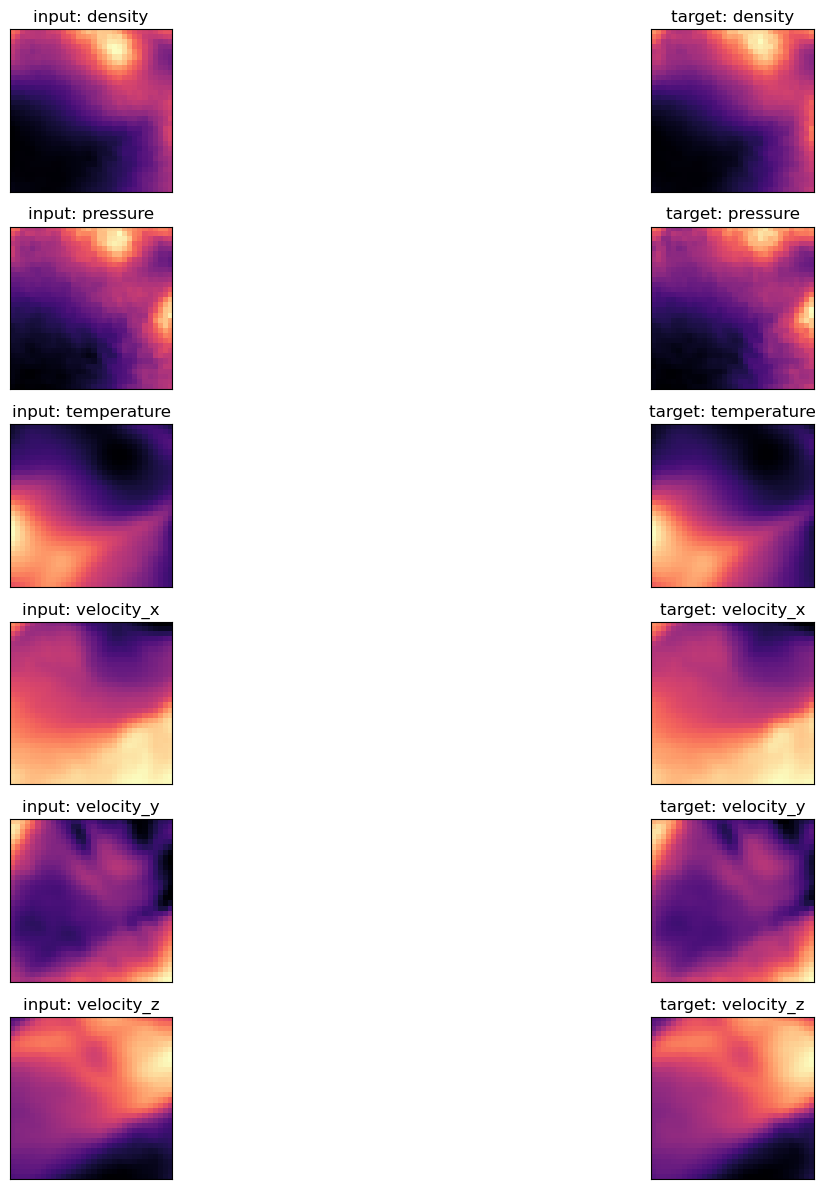

In [7]:
# [Cell 6] — Visualize one-step input/output slices by physical field
# -----------------------------------------------------------------------------

def plot_named_field_pair(
    x: torch.Tensor,
    y: torch.Tensor,
    z_slice: Optional[int] = None,
    use_log_for_scalars: bool = False,
    figsize: Tuple[int, int] = (18, 12),
):
    x = x.detach().cpu()
    y = y.detach().cpu()

    _, D, H, W = x.shape
    z_slice = D // 2 if z_slice is None else z_slice

    fig, axs = plt.subplots(len(FIELD_NAMES), 2, figsize=figsize)

    for i, name in enumerate(FIELD_NAMES):
        xin = x[i, z_slice]
        yout = y[i, z_slice]

        if use_log_for_scalars and name in SCALAR_FIELD_NAMES:
            xin = torch.log(torch.clamp(xin, min=1e-12))
            yout = torch.log(torch.clamp(yout, min=1e-12))

        axs[i, 0].imshow(xin.numpy(), cmap="magma")
        axs[i, 0].set_title(f"input: {name}")
        axs[i, 0].set_xticks([])
        axs[i, 0].set_yticks([])

        axs[i, 1].imshow(yout.numpy(), cmap="magma")
        axs[i, 1].set_title(f"target: {name}")
        axs[i, 1].set_xticks([])
        axs[i, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

plot_named_field_pair(sample0["x"], sample0["y"], use_log_for_scalars=False)

[CACHE HIT] quartet <- quartet_temperature_59230c647ea1d305_frames4.npz


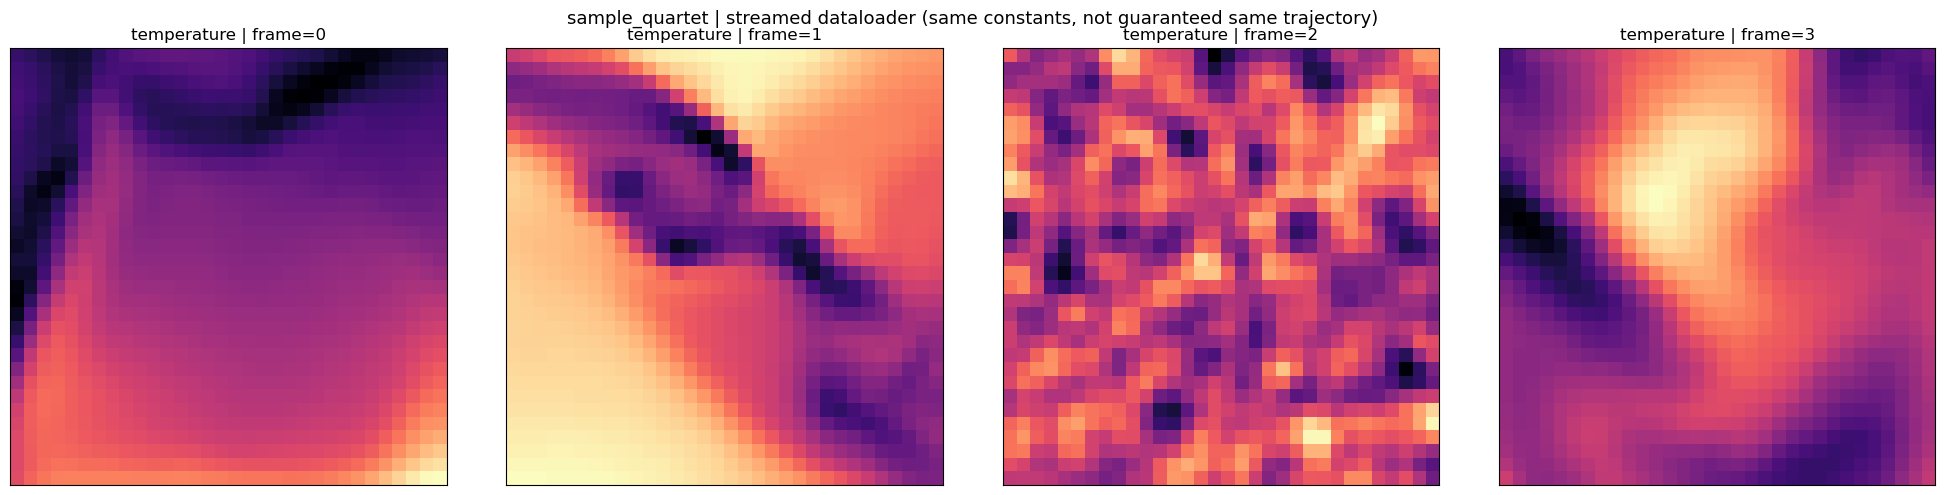

[CACHE HIT] quartet <- quartet_density_59230c647ea1d305_frames4.npz


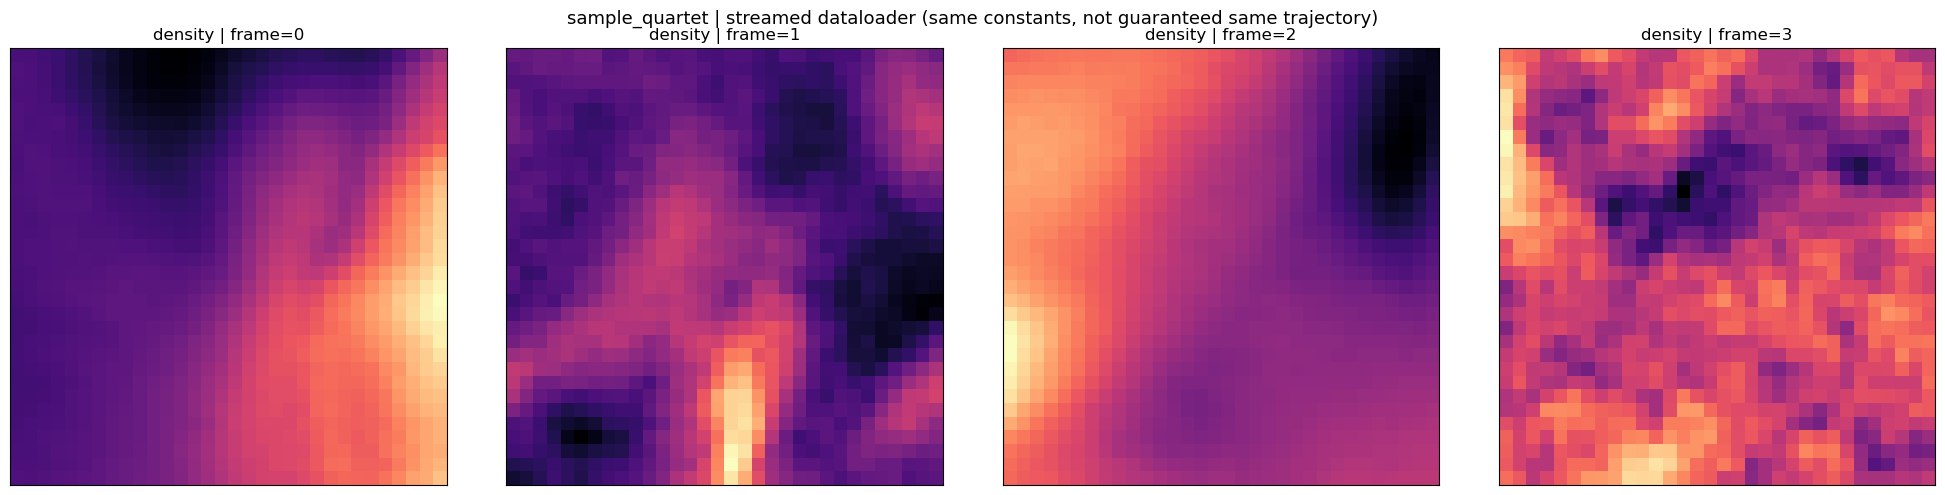

[CACHE HIT] quartet <- quartet_velocity_magnitude_59230c647ea1d305_frames4.npz


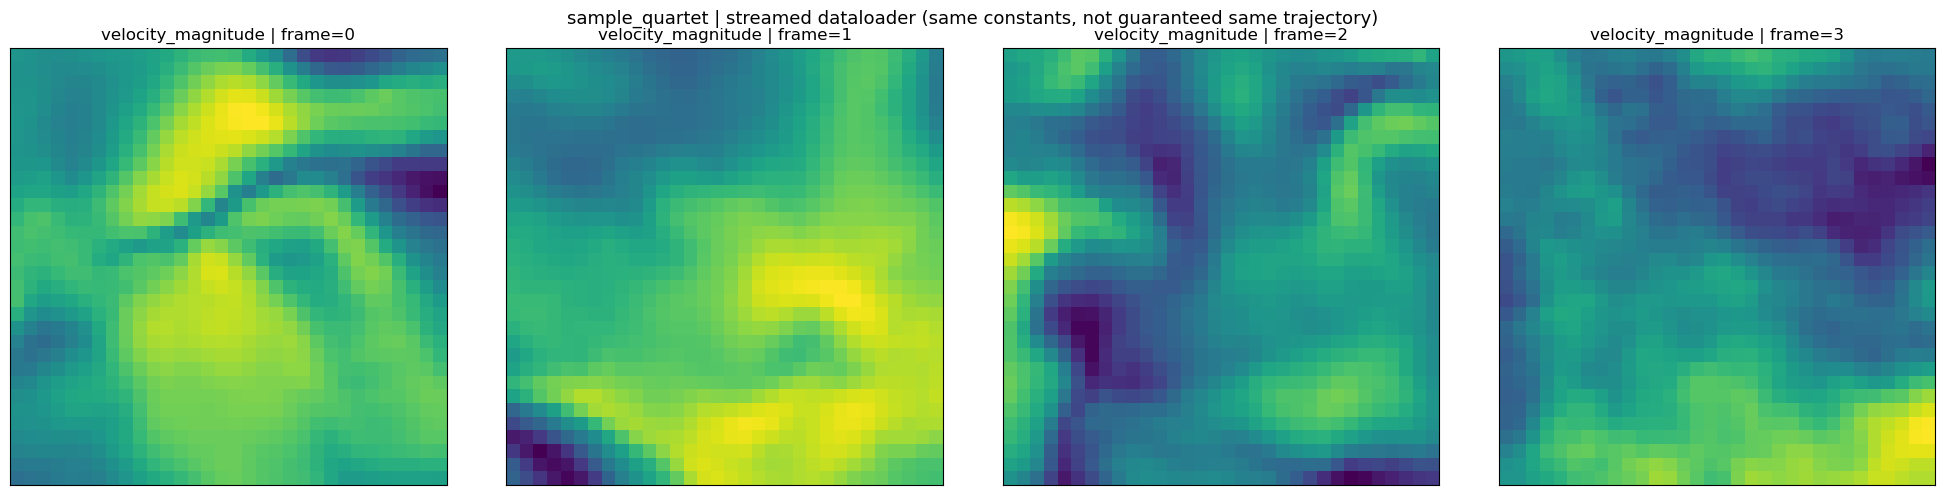

In [8]:
# [Cell 7] — Source-style snapshots with persistent cache
# -----------------------------------------------------------------------------
# POLICY
# 1. If local raw HDF5 exists, use true trajectory directly.
# 2. Else if streamed quartet cache exists, load it and DO NOT stream.
# 3. Else stream once, build quartet, save to disk, and reuse forever after.

import numpy as np

def load_full_field_trajectory_from_h5(
    path: Path,
    field_name: str,
    traj_idx: int = 0,
) -> np.ndarray:
    with h5py.File(path, "r") as f:
        if field_name in ["density", "pressure", "temperature"]:
            arr = f["t0_fields"][field_name][traj_idx]
        elif field_name in ["velocity_x", "velocity_y", "velocity_z"]:
            vel = f["t1_fields"]["velocity"][traj_idx]
            comp_idx = {"velocity_x": 0, "velocity_y": 1, "velocity_z": 2}[field_name]
            if vel.ndim == 5 and vel.shape[-1] == 3:
                arr = vel[..., comp_idx]
            else:
                arr = vel[:, comp_idx]
        elif field_name == "velocity_magnitude":
            vel = f["t1_fields"]["velocity"][traj_idx]
            if vel.ndim == 5 and vel.shape[-1] == 3:
                arr = np.sqrt((vel ** 2).sum(axis=-1) + 1e-12)
            else:
                arr = np.sqrt((vel ** 2).sum(axis=1) + 1e-12)
        else:
            raise ValueError(f"Unknown field_name: {field_name}")
    return arr

def gather_matching_samples_from_loader(
    loader,
    target_constants: Tuple[float, float, float],
    max_samples: int = 4,
):
    out = []
    target_rho0, target_Z, target_T0 = target_constants

    for raw_batch in loader:
        batch = canonicalize_tgc_batch(raw_batch)
        B = batch["x"].shape[0]
        for bi in range(B):
            s = extract_single_sample_from_batch(batch, sample_idx=bi, apply_crop=True)
            if (
                abs(s["rho0"] - target_rho0) < 1e-12 and
                abs(s["Z"] - target_Z) < 1e-12 and
                abs(s["T0"] - target_T0) < 1e-12
            ):
                out.append(s)
                if len(out) >= max_samples:
                    return out
    return out

def build_streamed_sample_quartet(
    loader,
    field_name: str,
    anchor_sample: dict,
    max_frames: int = 4,
) -> np.ndarray:
    matched = gather_matching_samples_from_loader(
        loader,
        target_constants=(anchor_sample["rho0"], anchor_sample["Z"], anchor_sample["T0"]),
        max_samples=max_frames,
    )

    if len(matched) == 0:
        matched = [anchor_sample]

    idx = FIELD_TO_INDEX[field_name] if field_name in FIELD_TO_INDEX else None

    frames = []
    for s in matched:
        if field_name == "velocity_magnitude":
            frames.append(velocity_magnitude(s["x"]).numpy())
        else:
            frames.append(s["x"][idx].numpy())

    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.stack(frames, axis=0)

def get_proxy_or_true_trajectory(
    field_name: str,
    anchor_sample: dict,
    traj_idx: int = 0,
    max_frames: int = 4,
):
    if len(RAW_FILES) > 0:
        traj = load_full_field_trajectory_from_h5(
            RAW_FILES[-1],
            field_name=field_name,
            traj_idx=traj_idx,
        )
        source = f"true_trajectory | local_hdf5: {RAW_FILES[-1].name}"
        return traj, source

    cpath = quartet_cache_path(anchor_sample, field_name, max_frames=max_frames)
    if cpath.exists():
        cached = load_npz_quartet(cpath)
        print(f"[CACHE HIT] quartet <- {cpath.name}")
        return cached["traj"], cached["meta"].get("source", "cached_streamed_quartet")

    print(f"[CACHE MISS] building streamed quartet for field={field_name}")
    traj = build_streamed_sample_quartet(
        train_loader,
        field_name=field_name,
        anchor_sample=anchor_sample,
        max_frames=max_frames,
    )
    source = "sample_quartet | streamed dataloader (same constants, not guaranteed same trajectory)"
    save_npz_quartet(
        cpath,
        traj,
        meta={
            "field_name": field_name,
            "rho0": anchor_sample["rho0"],
            "Z": anchor_sample["Z"],
            "T0": anchor_sample["T0"],
            "max_frames": max_frames,
            "source": source,
        },
    )
    print(f"[CACHE SAVED] quartet -> {cpath}")
    return traj, source

def plot_field_trajectory_snapshots(
    field_name: str = "temperature",
    traj_idx: int = 0,
    x_slice: int = 16,
    log_plot: bool = False,
    cmap: str = "magma",
    max_frames: int = 4,
    return_traj: bool = False,
):
    traj, source = get_proxy_or_true_trajectory(
        field_name=field_name,
        anchor_sample=sample0,
        traj_idx=traj_idx,
        max_frames=max_frames,
    )

    T = traj.shape[0]
    frames = [0, max(0, T // 3), max(0, (2 * T) // 3), T - 1]

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for i, t in enumerate(frames):
        img = traj[t, x_slice]
        if log_plot:
            img = np.log(np.clip(img, 1e-12, None))
        axs[i].imshow(img, cmap=cmap)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_title(f"{field_name} | frame={t}")

    fig.suptitle(source, fontsize=13)
    plt.tight_layout()
    plt.show()

    if return_traj:
        return traj, source

plot_field_trajectory_snapshots(field_name="temperature", x_slice=16, log_plot=True)
plot_field_trajectory_snapshots(field_name="density", x_slice=16, log_plot=True)
plot_field_trajectory_snapshots(field_name="velocity_magnitude", x_slice=16, log_plot=False, cmap="viridis")

[CACHE HIT] quartet <- quartet_density_59230c647ea1d305_frames4.npz
[CACHE HIT] quartet <- quartet_pressure_59230c647ea1d305_frames4.npz
[CACHE HIT] quartet <- quartet_temperature_59230c647ea1d305_frames4.npz
[CACHE HIT] quartet <- quartet_velocity_magnitude_59230c647ea1d305_frames4.npz


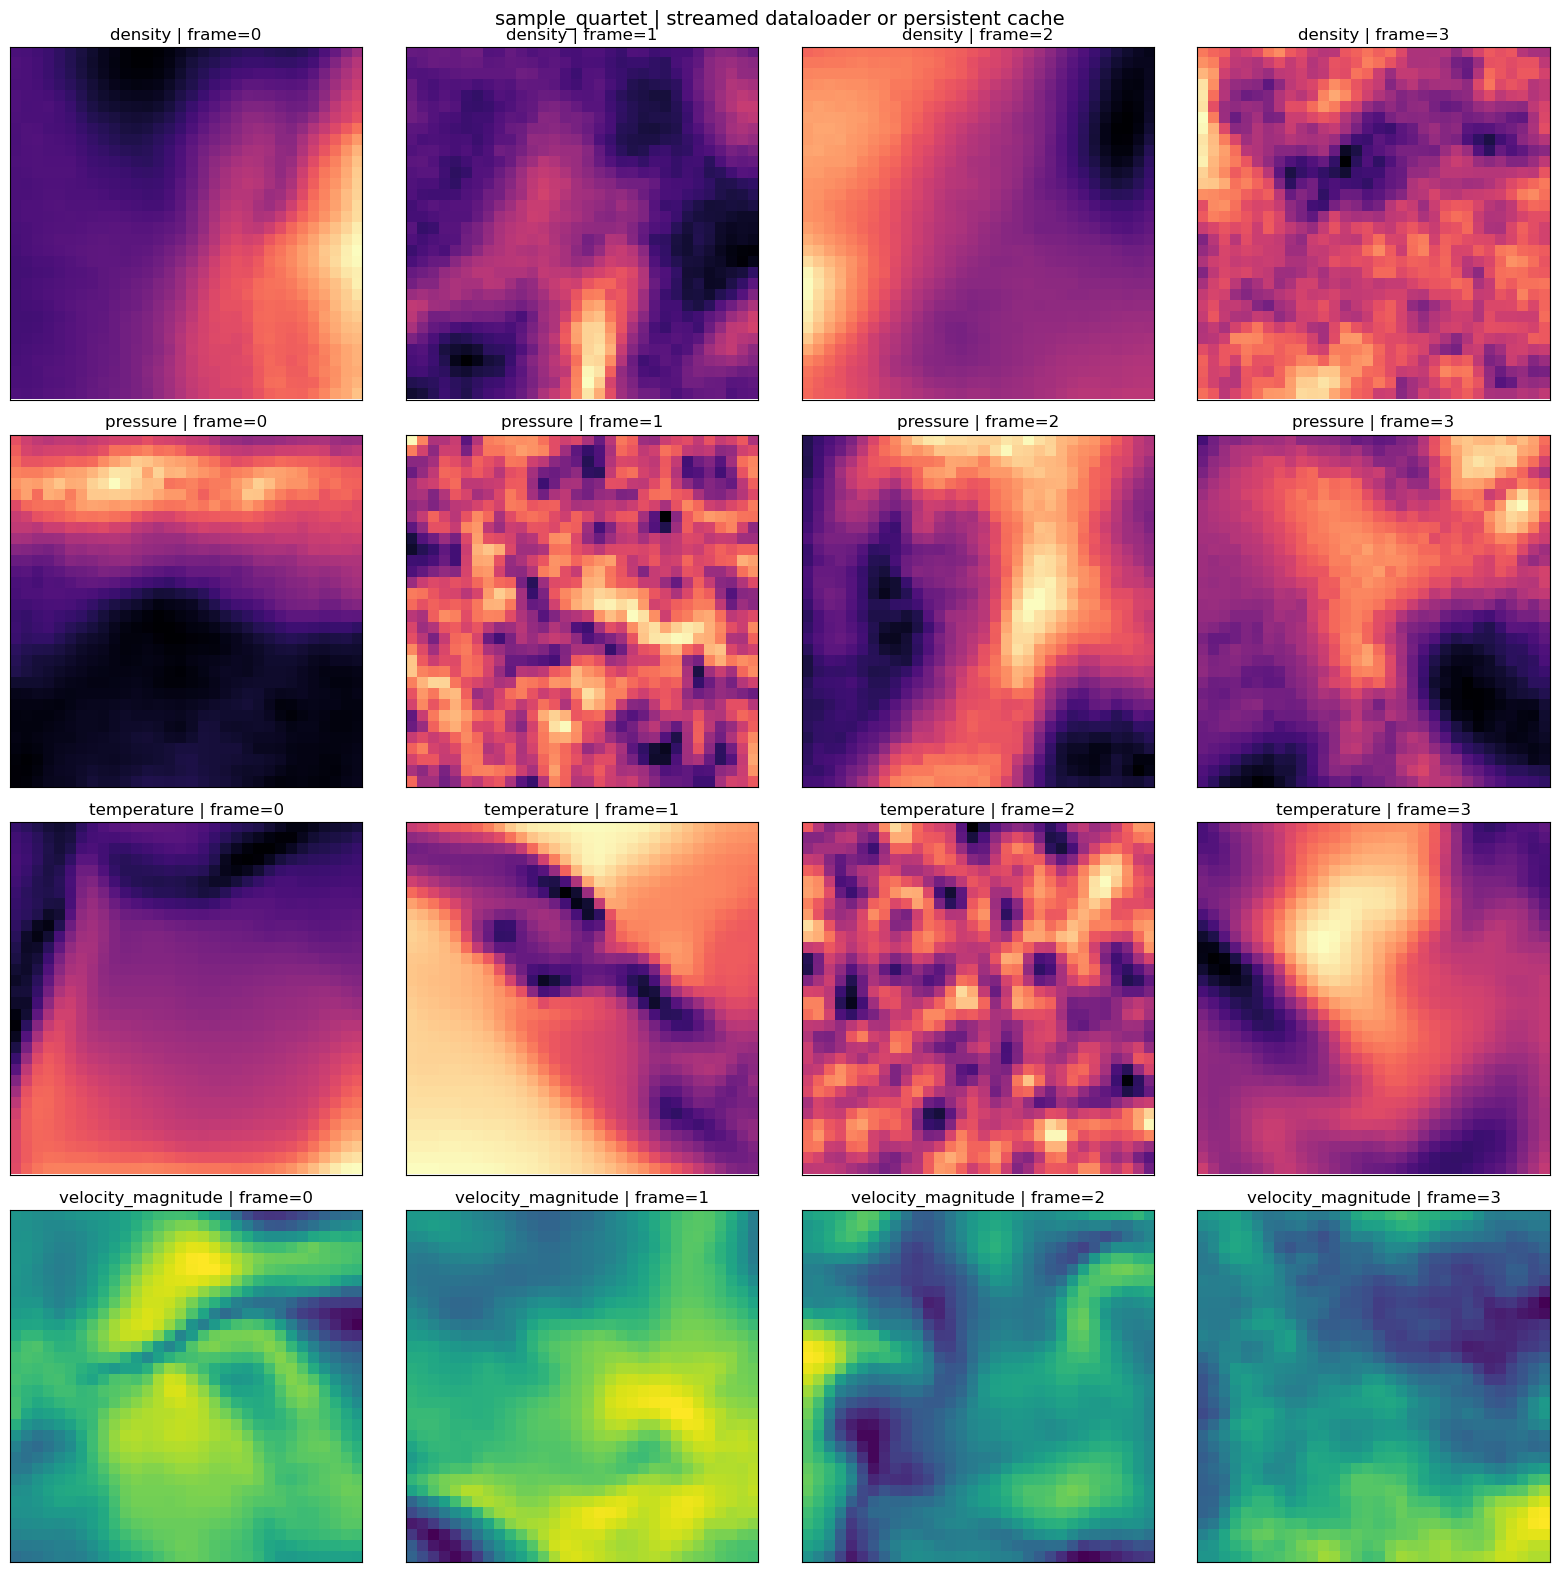

In [ ]:
# [Cell 8] — Higher-level visualization for thermodynamics and flow structure
# -----------------------------------------------------------------------------

def plot_system_summary_grid(
    traj_idx: int = 0,
    x_slice: int = 16,
    times: Optional[List[int]] = None,
):
    fields = ["density", "pressure", "temperature", "velocity_magnitude"]

    if len(RAW_FILES) > 0:
        data = {f: load_full_field_trajectory_from_h5(RAW_FILES[-1], f, traj_idx=traj_idx) for f in fields}
        source = f"true_trajectory | local_hdf5: {RAW_FILES[-1].name}"
    else:
        data = {}
        for f in fields:
            traj, _ = get_proxy_or_true_trajectory(
                field_name=f,
                anchor_sample=sample0,
                traj_idx=traj_idx,
                max_frames=4,
            )
            data[f] = traj
        source = "sample_quartet | streamed dataloader or persistent cache"

    T = next(iter(data.values())).shape[0]
    if times is None:
        times = [0, max(0, T // 3), max(0, (2 * T) // 3), T - 1]

    fig, axs = plt.subplots(len(fields), len(times), figsize=(4 * len(times), 4 * len(fields)))

    for r, field_name in enumerate(fields):
        for c, t in enumerate(times):
            img = data[field_name][t, x_slice]
            if field_name in ["density", "pressure", "temperature"]:
                img = np.log(np.clip(img, 1e-12, None))
                cmap = "magma"
            else:
                cmap = "viridis"

            axs[r, c].imshow(img, cmap=cmap)
            axs[r, c].set_xticks([])
            axs[r, c].set_yticks([])
            axs[r, c].set_title(f"{field_name} | frame={t}")

    fig.suptitle(source, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_system_summary_grid(traj_idx=0, x_slice=16)

In [ ]:
# [Cell 9] — Build a physically meaningful agent context pack
# -----------------------------------------------------------------------------

def make_tgc_context_pack(sample: Dict[str, Any]) -> Dict[str, Any]:
    x = sample["x"]

    field_stats = describe_named_fields(x)

    data_source_mode = "local_hdf5_or_stream_cache" if len(RAW_FILES) > 0 else "stream_cache_first"

    pack = {
        "task": "3d_turbulence_gravity_cooling_one_step_forecast",
        "dataset_name": "turbulence_gravity_cooling",
        "grid_type": META["grid_type"],
        "spatial_resolution": META["spatial_resolution"],
        "boundary_conditions": META["boundary_condition_types"],
        "fields": FIELD_NAMES,
        "constant_scalars": {
            "rho0": sample["rho0"],
            "Z": sample["Z"],
            "T0": sample["T0"],
        },
        "input_field_stats": field_stats,
        "time_info": {
            "input_time": sample["input_time"],
            "output_time": sample["output_time"],
            "dt": sample["dt"],
        },
        "notes": {
            "physics_regime": "gravity + hydrodynamics + radiative cooling/heating",
            "dense_regions": "important for star-formation-related structure",
            "vector_field_present": True,
            "data_source_mode": data_source_mode,
        },
    }
    return pack

context_pack = make_tgc_context_pack(sample0)
display(Markdown("## Agent context pack"))
print(json.dumps(context_pack, indent=2))

## Agent context pack

{
  "task": "3d_turbulence_gravity_cooling_one_step_forecast",
  "dataset_name": "turbulence_gravity_cooling",
  "grid_type": "cartesian",
  "spatial_resolution": [
    64,
    64,
    64
  ],
  "boundary_conditions": [
    "OPEN"
  ],
  "fields": [
    "density",
    "pressure",
    "temperature",
    "velocity_x",
    "velocity_y",
    "velocity_z"
  ],
  "constant_scalars": {
    "rho0": 0.4449999928474426,
    "Z": 1.0,
    "T0": 1000.0
  },
  "input_field_stats": {
    "density": {
      "mean": 0.152433380484581,
      "std": 0.07528352737426758,
      "min": 0.0427430234849453,
      "max": 0.8871809840202332
    },
    "pressure": {
      "mean": 0.044727426022291183,
      "std": 0.012219073250889778,
      "min": 0.024690283462405205,
      "max": 0.13396218419075012
    },
    "temperature": {
      "mean": 371.64080810546875,
      "std": 102.73966979980469,
      "min": 166.423828125,
      "max": 677.279296875
    },
    "velocity_x": {
      "mean": -0.02110454812645912,

In [ ]:
# [Cell 10] — Lightweight 3D forecaster for practical debugging
# -----------------------------------------------------------------------------
# PURPOSE
# Use a small residual 3D CNN forecaster instead of jumping immediately into
# heavy FNO variants. This is more practical for fast notebook iteration.
#
# MODEL
# -----
# Input:  [B, 6, D, H, W]
# Output: [B, 6, D, H, W]
#
# Predict next-step delta:
#   y_hat = x + f(x)
# -----------------------------------------------------------------------------

class ResBlock3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm3d(channels)
        self.norm2 = nn.BatchNorm3d(channels)

    def forward(self, x):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.gelu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return F.gelu(x + h)

class TGCForecaster3D(nn.Module):
    def __init__(self, in_ch: int = 6, hidden: int = 32, depth: int = 4):
        super().__init__()
        self.in_proj = nn.Conv3d(in_ch, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, in_ch, kernel_size=3, padding=1)

    def forward(self, x):
        h = self.in_proj(x)
        h = F.gelu(h)
        for blk in self.blocks:
            h = blk(h)
        delta = self.out_proj(h)
        return x + delta

model = TGCForecaster3D().to(DEVICE)
print(model.__class__.__name__)
print(f"parameters = {sum(p.numel() for p in model.parameters()):,}")

TGCForecaster3D
parameters = 232,358


In [ ]:
# [Cell 11] — Physics-aware losses and field-aware metrics
# -----------------------------------------------------------------------------
# PURPOSE
# Keep the baseline data-fit term, but add targeted structure-preserving terms
# that better reflect the scientific priorities of turbulence_gravity_cooling.
#
# LOSS TERMS
# ----------
# 1. global data MSE
# 2. extra density-channel loss
# 3. dense-region weighted density loss
# 4. density-gradient consistency
# 5. velocity-magnitude consistency
# 6. light mass-consistency penalty
# -----------------------------------------------------------------------------

def channelwise_mse(y_hat: torch.Tensor, y: torch.Tensor) -> Dict[str, float]:
    out = {}
    for i, name in enumerate(FIELD_NAMES):
        out[name] = float(F.mse_loss(y_hat[:, i], y[:, i]).item())
    return out

def relative_l2(pred: torch.Tensor, truth: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.linalg.norm((pred - truth).reshape(-1))
    den = torch.linalg.norm(truth.reshape(-1)) + eps
    return float((num / den).item())

def evaluate_batch_metrics(y_hat: torch.Tensor, y: torch.Tensor) -> Dict[str, Any]:
    mse_by_field = channelwise_mse(y_hat, y)

    rel_by_field = {}
    for i, name in enumerate(FIELD_NAMES):
        rel_by_field[name] = relative_l2(y_hat[:, i], y[:, i])

    velmag_hat = velocity_magnitude(y_hat)
    velmag_true = velocity_magnitude(y)
    velmag_rel = relative_l2(velmag_hat, velmag_true)

    return {
        "mse_by_field": mse_by_field,
        "rel_l2_by_field": rel_by_field,
        "velocity_magnitude_rel_l2": velmag_rel,
        "global_mse": float(F.mse_loss(y_hat, y).item()),
    }

# -----------------------------------------------------------------------------
# Gradient helpers
# -----------------------------------------------------------------------------
def finite_diff_axis_3d(x: torch.Tensor, axis: int) -> torch.Tensor:
    """
    x: [B, D, H, W]
    axis: one of 1,2,3 relative to [B,D,H,W]
    Uses centered finite difference via roll.
    """
    return 0.5 * (torch.roll(x, shifts=-1, dims=axis) - torch.roll(x, shifts=1, dims=axis))

def gradient_magnitude_3d(x: torch.Tensor) -> torch.Tensor:
    """
    x: [B, D, H, W]
    """
    gx = finite_diff_axis_3d(x, 1)
    gy = finite_diff_axis_3d(x, 2)
    gz = finite_diff_axis_3d(x, 3)
    return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-12)

# -----------------------------------------------------------------------------
# Dense-region masks
# -----------------------------------------------------------------------------
def dense_region_mask(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    """
    Input:
      x: [B, C, D, H, W] or [C, D, H, W]
    Returns:
      boolean mask over density field
    """
    if x.ndim == 4:
        density = x[FIELD_TO_INDEX["density"]]
        thresh = torch.quantile(density.reshape(-1), quantile)
        return density >= thresh

    density = x[:, FIELD_TO_INDEX["density"]]
    flat = density.reshape(density.shape[0], -1)
    thresh = torch.quantile(flat, quantile, dim=1, keepdim=True)
    thresh = thresh.view(-1, 1, 1, 1)
    return density >= thresh

# -----------------------------------------------------------------------------
# Physics-aware multi-term loss
# -----------------------------------------------------------------------------
LOSS_WEIGHTS = {
    "global_mse": 1.0,
    "density_mse": 1.0,
    "dense_region_density": 2.0,
    "density_gradient": 0.5,
    "velocity_magnitude": 0.25,
    "mass_consistency": 0.1,
}

def compute_loss_terms(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
    dense_quantile: float = 0.95,
) -> Dict[str, torch.Tensor]:
    """
    x     : input  [B, C, D, H, W]
    y_hat : pred   [B, C, D, H, W]
    y     : target [B, C, D, H, W]
    """
    density_idx = FIELD_TO_INDEX["density"]

    # 1. baseline global fit
    global_mse = F.mse_loss(y_hat, y)

    # 2. explicit density-channel fit
    density_hat = y_hat[:, density_idx]
    density_true = y[:, density_idx]
    density_mse = F.mse_loss(density_hat, density_true)

    # 3. dense-region weighted density error
    dense_mask = dense_region_mask(y, quantile=dense_quantile).float()
    dense_region_density = ((density_hat - density_true) ** 2 * dense_mask).sum() / (dense_mask.sum() + 1e-12)

    # 4. density gradient / morphology consistency
    grad_hat = gradient_magnitude_3d(density_hat)
    grad_true = gradient_magnitude_3d(density_true)
    density_gradient = F.l1_loss(grad_hat, grad_true)

    # 5. velocity magnitude consistency
    velmag_hat = velocity_magnitude(y_hat)
    velmag_true = velocity_magnitude(y)
    velocity_magnitude_term = F.mse_loss(velmag_hat, velmag_true)

    # 6. light mass-consistency term
    # Encourage the global density mass change to match target one-step change.
    mass_hat = density_hat.mean(dim=(1, 2, 3))
    mass_true = density_true.mean(dim=(1, 2, 3))
    mass_consistency = F.mse_loss(mass_hat, mass_true)

    return {
        "global_mse": global_mse,
        "density_mse": density_mse,
        "dense_region_density": dense_region_density,
        "density_gradient": density_gradient,
        "velocity_magnitude": velocity_magnitude_term,
        "mass_consistency": mass_consistency,
    }

def compute_loss(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
) -> torch.Tensor:
    terms = compute_loss_terms(x, y_hat, y)
    total = 0.0
    for k, v in terms.items():
        total = total + LOSS_WEIGHTS[k] * v
    return total

def compute_loss_breakdown(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
) -> Dict[str, float]:
    terms = compute_loss_terms(x, y_hat, y)
    out = {k: float(v.detach().item()) for k, v in terms.items()}
    out["total"] = float(sum(LOSS_WEIGHTS[k] * terms[k] for k in terms).detach().item())
    return out

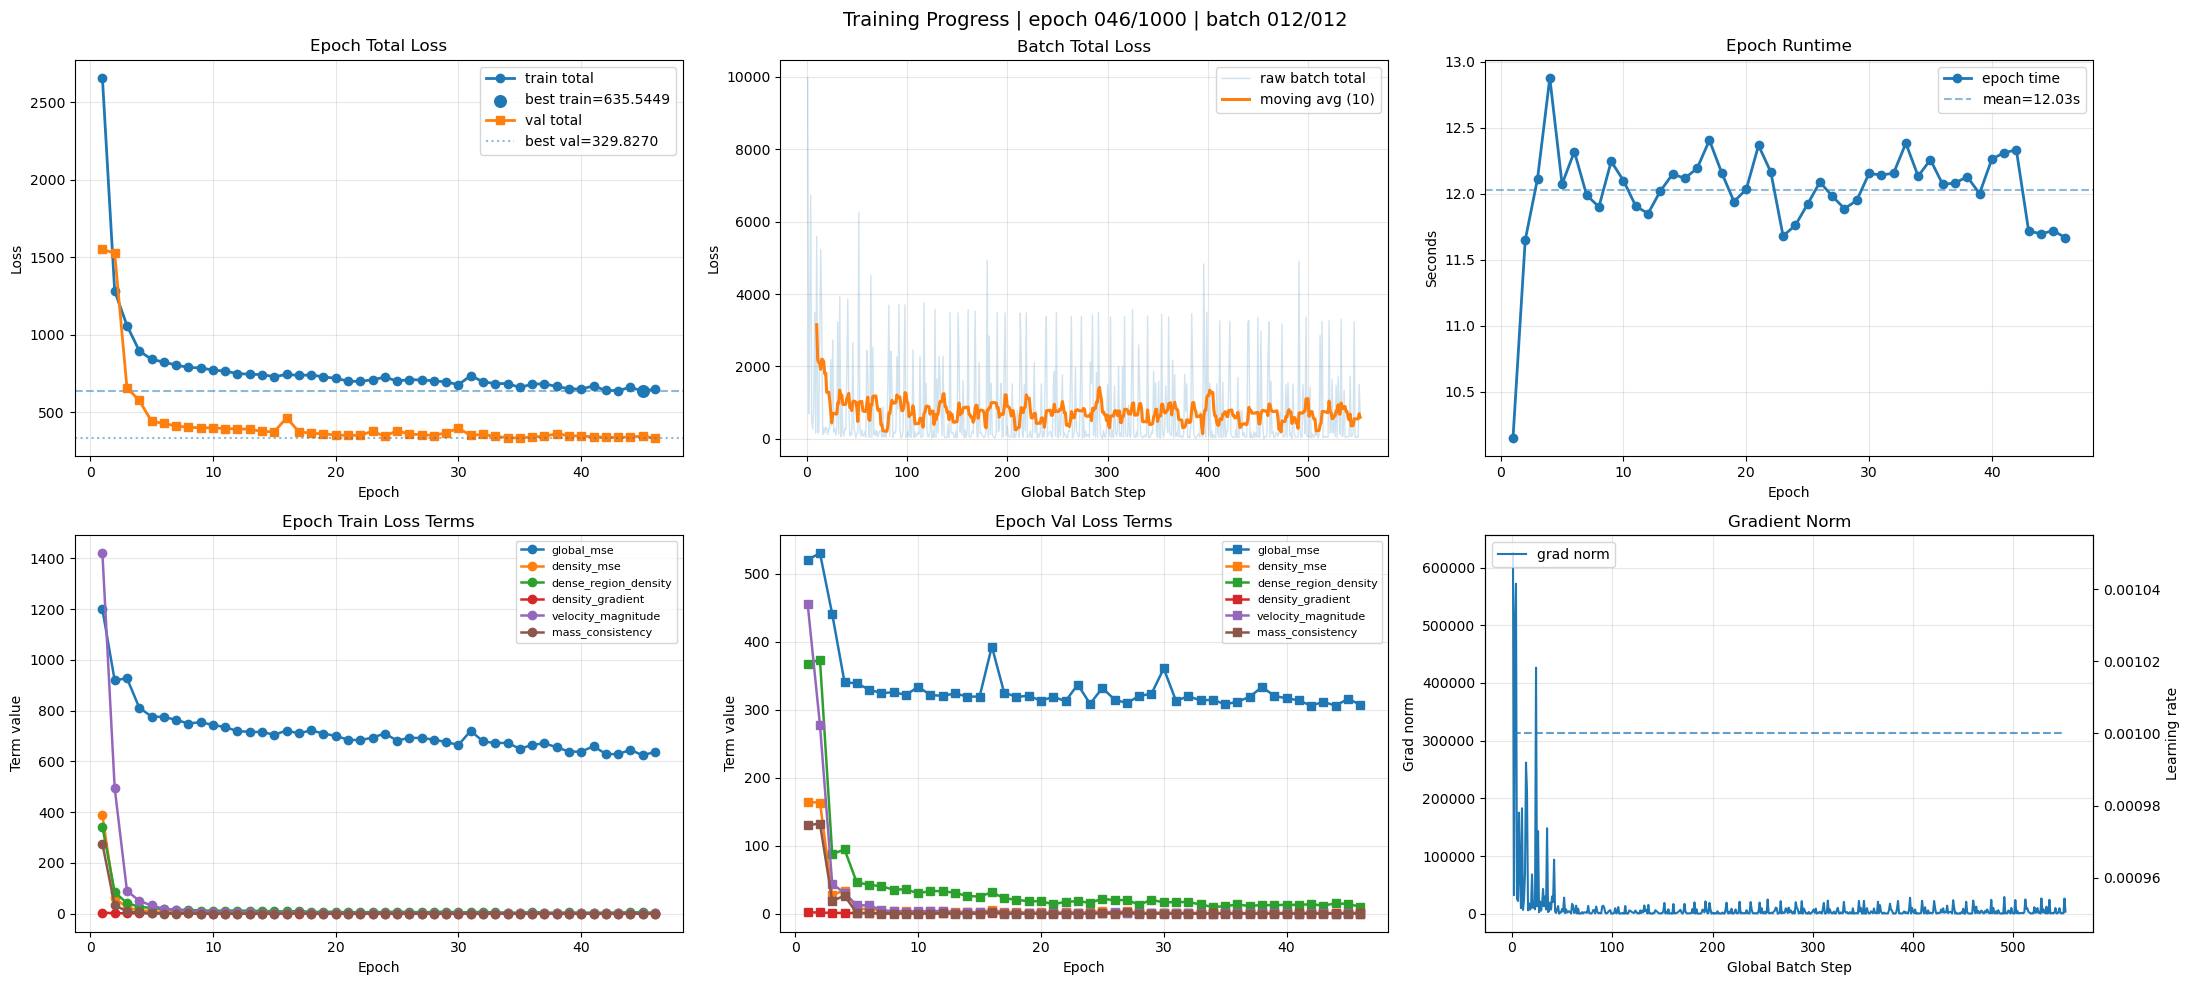

[EPOCH DONE] 046/1000 | epoch time 11.67s
last batch total loss   : 735.749146
last epoch train total  : 647.979306
best train total        : 635.544905
last epoch val total    : 329.827043
best val total          : 329.827043
mean epoch time         : 12.03s
rough ETA remaining     : 11472.73s
last grad norm          : 3653.869566

last batch term breakdown:
  global_mse            : 728.422119
  density_mse           : 0.935016
  dense_region_density  : 3.018126
  density_gradient      : 0.429931
  velocity_magnitude    : 0.557696
  mass_consistency      : 0.014008


In [ ]:
# [Cell 12] — Training loop with comprehensive live plotting and loss breakdown
# -----------------------------------------------------------------------------
# PURPOSE
# Train with detailed live feedback for the new physics-aware multi-term loss.
#
# FEATURES
# --------
# 1. Live batch-level updates during each epoch
# 2. Epoch-average train / val total loss
# 3. Smoothed batch total loss
# 4. Epoch runtime tracking
# 5. Best-so-far annotation
# 6. Per-term loss tracking for:
#    - global_mse
#    - density_mse
#    - dense_region_density
#    - density_gradient
#    - velocity_magnitude
#    - mass_consistency
# 7. Gradient-norm tracking
# 8. Optional checkpointing of best model
# -----------------------------------------------------------------------------

from dataclasses import dataclass, field
from typing import List, Dict, Optional
import math
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# -----------------------------------------------------------------------------
# History container
# -----------------------------------------------------------------------------
@dataclass
class TrainHistory:
    train_total_loss: List[float] = field(default_factory=list)
    val_total_loss: List[float] = field(default_factory=list)
    epoch_time_sec: List[float] = field(default_factory=list)

    batch_total_loss: List[float] = field(default_factory=list)
    batch_step: List[int] = field(default_factory=list)
    learning_rate: List[float] = field(default_factory=list)
    grad_norm: List[float] = field(default_factory=list)

    train_loss_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "global_mse": [],
        "density_mse": [],
        "dense_region_density": [],
        "density_gradient": [],
        "velocity_magnitude": [],
        "mass_consistency": [],
    })
    val_loss_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "global_mse": [],
        "density_mse": [],
        "dense_region_density": [],
        "density_gradient": [],
        "velocity_magnitude": [],
        "mass_consistency": [],
    })

    batch_loss_terms_last: Dict[str, float] = field(default_factory=dict)

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def moving_average(x, window: int = 20):
    if len(x) == 0:
        return np.array([])
    x = np.asarray(x, dtype=float)
    window = max(1, min(window, len(x)))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def compute_grad_norm(model: nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            total += float(torch.sum(g * g).item())
    return math.sqrt(total) if total > 0 else 0.0

@torch.no_grad()
def evaluate_loader_loss_breakdown(
    model: nn.Module,
    loader: DataLoader,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    model.eval()

    totals = []
    term_sums = {
        "global_mse": [],
        "density_mse": [],
        "dense_region_density": [],
        "density_gradient": [],
        "velocity_magnitude": [],
        "mass_consistency": [],
    }

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)

        y_hat = model(x)
        breakdown = compute_loss_breakdown(x, y_hat, y)

        totals.append(float(breakdown["total"]))
        for k in term_sums:
            term_sums[k].append(float(breakdown[k]))

    out = {}
    out["total"] = float(np.mean(totals)) if len(totals) > 0 else float("nan")
    for k, vals in term_sums.items():
        out[k] = float(np.mean(vals)) if len(vals) > 0 else float("nan")
    return out

def _safe_last(xs, default=None):
    return xs[-1] if len(xs) > 0 else default

# -----------------------------------------------------------------------------
# Plotter
# -----------------------------------------------------------------------------
def plot_training_history_live(
    history: TrainHistory,
    epoch: int,
    epochs: int,
    current_epoch_batch: int,
    total_batches: int,
    refresh_text: Optional[str] = None,
    batch_ma_window: int = 20,
):
    fig, axs = plt.subplots(2, 3, figsize=(22, 10))

    # -------------------------------------------------------------------------
    # Panel 1: epoch total losses
    # -------------------------------------------------------------------------
    ax = axs[0, 0]
    if len(history.train_total_loss) > 0:
        x = np.arange(1, len(history.train_total_loss) + 1)
        ax.plot(x, history.train_total_loss, marker="o", linewidth=2, label="train total")
        best_idx = int(np.argmin(history.train_total_loss))
        best_val = history.train_total_loss[best_idx]
        ax.scatter(best_idx + 1, best_val, s=70, label=f"best train={best_val:.4f}")
        ax.axhline(best_val, linestyle="--", alpha=0.5)

    if len(history.val_total_loss) > 0:
        x = np.arange(1, len(history.val_total_loss) + 1)
        ax.plot(x, history.val_total_loss, marker="s", linewidth=2, label="val total")

        valid_vals = [v for v in history.val_total_loss if v is not None and math.isfinite(v)]
        if len(valid_vals) > 0:
            best_val = min(valid_vals)
            ax.axhline(best_val, linestyle=":", alpha=0.5, label=f"best val={best_val:.4f}")

    ax.set_title("Epoch Total Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # -------------------------------------------------------------------------
    # Panel 2: batch total loss
    # -------------------------------------------------------------------------
    ax = axs[0, 1]
    if len(history.batch_total_loss) > 0:
        ax.plot(
            history.batch_step,
            history.batch_total_loss,
            alpha=0.20,
            linewidth=1.0,
            label="raw batch total",
        )

        ma = moving_average(history.batch_total_loss, window=batch_ma_window)
        if len(ma) > 0:
            ma_steps = history.batch_step[len(history.batch_step) - len(ma):]
            ax.plot(
                ma_steps,
                ma,
                linewidth=2.2,
                label=f"moving avg ({batch_ma_window})",
            )

    ax.set_title("Batch Total Loss")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # -------------------------------------------------------------------------
    # Panel 3: epoch runtime
    # -------------------------------------------------------------------------
    ax = axs[0, 2]
    if len(history.epoch_time_sec) > 0:
        x = np.arange(1, len(history.epoch_time_sec) + 1)
        ax.plot(x, history.epoch_time_sec, marker="o", linewidth=2, label="epoch time")
        ax.axhline(np.mean(history.epoch_time_sec), linestyle="--", alpha=0.5,
                   label=f"mean={np.mean(history.epoch_time_sec):.2f}s")

    ax.set_title("Epoch Runtime")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Seconds")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # -------------------------------------------------------------------------
    # Panel 4: epoch train loss term breakdown
    # -------------------------------------------------------------------------
    ax = axs[1, 0]
    plotted_any = False
    for k, vals in history.train_loss_terms.items():
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.8, label=k)
            plotted_any = True
    ax.set_title("Epoch Train Loss Terms")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Term value")
    ax.grid(True, alpha=0.3)
    if plotted_any:
        ax.legend(fontsize=8)

    # -------------------------------------------------------------------------
    # Panel 5: epoch val loss term breakdown
    # -------------------------------------------------------------------------
    ax = axs[1, 1]
    plotted_any = False
    for k, vals in history.val_loss_terms.items():
        finite_vals = [v for v in vals if v is not None and math.isfinite(v)]
        if len(finite_vals) > 0:
            x = np.arange(1, len(vals) + 1)
            ax.plot(x, vals, marker="s", linewidth=1.8, label=k)
            plotted_any = True
    ax.set_title("Epoch Val Loss Terms")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Term value")
    ax.grid(True, alpha=0.3)
    if plotted_any:
        ax.legend(fontsize=8)

    # -------------------------------------------------------------------------
    # Panel 6: gradient norm + learning rate
    # -------------------------------------------------------------------------
    ax = axs[1, 2]
    if len(history.grad_norm) > 0:
        ax.plot(history.batch_step, history.grad_norm, linewidth=1.5, label="grad norm")
    ax.set_title("Gradient Norm")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Grad norm")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    if len(history.learning_rate) > 0:
        ax2.plot(history.batch_step, history.learning_rate, linestyle="--", alpha=0.7, label="lr")
    ax2.set_ylabel("Learning rate")

    fig.suptitle(
        f"Training Progress | epoch {epoch:03d}/{epochs:03d} | "
        f"batch {current_epoch_batch:03d}/{total_batches:03d}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # Text summary
    # -------------------------------------------------------------------------
    if refresh_text is not None:
        print(refresh_text)

    if len(history.batch_total_loss) > 0:
        print(f"last batch total loss   : {history.batch_total_loss[-1]:.6f}")

    if len(history.train_total_loss) > 0:
        print(f"last epoch train total  : {history.train_total_loss[-1]:.6f}")
        print(f"best train total        : {float(np.min(history.train_total_loss)):.6f}")

    if len(history.val_total_loss) > 0:
        valid_vals = [v for v in history.val_total_loss if v is not None and math.isfinite(v)]
        if len(valid_vals) > 0:
            print(f"last epoch val total    : {history.val_total_loss[-1]:.6f}")
            print(f"best val total          : {float(np.min(valid_vals)):.6f}")

    if len(history.epoch_time_sec) > 0:
        mean_epoch_time = float(np.mean(history.epoch_time_sec))
        remaining_epochs = max(0, epochs - len(history.epoch_time_sec))
        eta_sec = mean_epoch_time * remaining_epochs
        print(f"mean epoch time         : {mean_epoch_time:.2f}s")
        print(f"rough ETA remaining     : {eta_sec:.2f}s")

    if len(history.grad_norm) > 0:
        print(f"last grad norm          : {history.grad_norm[-1]:.6f}")

    if len(history.batch_loss_terms_last) > 0:
        print("\nlast batch term breakdown:")
        for k, v in history.batch_loss_terms_last.items():
            print(f"  {k:22s}: {v:.6f}")

# -----------------------------------------------------------------------------
# Trainer
# -----------------------------------------------------------------------------
def train_model(
    model: nn.Module,
    loader: DataLoader,
    epochs: int,
    lr: float = 1e-3,
    val_loader: Optional[DataLoader] = None,
    validate_every: int = 1,
    val_max_batches: Optional[int] = 3,
    live_plot_every_batches: int = 1,
    batch_ma_window: int = 20,
    checkpoint_best: bool = True,
    best_ckpt_path: Optional[Path] = None,
) -> TrainHistory:
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = TrainHistory()
    global_step = 0
    total_batches = len(loader)

    if best_ckpt_path is None:
        best_ckpt_path = LOG_DIR / "best_tgc_model.pt"

    best_val = float("inf")
    best_train = float("inf")
    best_state = None

    for epoch in range(epochs):
        t0 = time.time()
        model.train()

        running_total = 0.0
        running_terms = {
            "global_mse": 0.0,
            "density_mse": 0.0,
            "dense_region_density": 0.0,
            "density_gradient": 0.0,
            "velocity_magnitude": 0.0,
            "mass_consistency": 0.0,
        }
        n_batches = 0

        for bi, batch in enumerate(loader, start=1):
            x = ensure_float32(batch["x"]).to(DEVICE)
            y = ensure_float32(batch["y"]).to(DEVICE)

            y_hat = model(x)
            loss = compute_loss(x, y_hat, y)
            breakdown = compute_loss_breakdown(x, y_hat, y)

            opt.zero_grad()
            loss.backward()
            grad_norm_val = compute_grad_norm(model)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            batch_total = float(loss.item())

            running_total += batch_total
            for k in running_terms:
                running_terms[k] += float(breakdown[k])
            n_batches += 1
            global_step += 1

            history.batch_total_loss.append(batch_total)
            history.batch_step.append(global_step)
            history.learning_rate.append(opt.param_groups[0]["lr"])
            history.grad_norm.append(grad_norm_val)
            history.batch_loss_terms_last = {
                k: float(breakdown[k]) for k in running_terms
            }

            if bi % live_plot_every_batches == 0 or bi == total_batches:
                elapsed = time.time() - t0
                mean_so_far = running_total / max(1, n_batches)
                msg = (
                    f"[LIVE] epoch {epoch+1:03d}/{epochs:03d} | "
                    f"batch {bi:03d}/{total_batches:03d} | "
                    f"elapsed {elapsed:.2f}s | "
                    f"running total {mean_so_far:.6f}"
                )
                clear_output(wait=True)
                plot_training_history_live(
                    history=history,
                    epoch=epoch + 1,
                    epochs=epochs,
                    current_epoch_batch=bi,
                    total_batches=total_batches,
                    refresh_text=msg,
                    batch_ma_window=batch_ma_window,
                )

        # ---------------------------------------------------------------------
        # End of epoch aggregation
        # ---------------------------------------------------------------------
        epoch_total = running_total / max(1, n_batches)
        epoch_time = time.time() - t0

        history.train_total_loss.append(epoch_total)
        history.epoch_time_sec.append(epoch_time)

        for k in running_terms:
            history.train_loss_terms[k].append(running_terms[k] / max(1, n_batches))

        # ---------------------------------------------------------------------
        # Validation
        # ---------------------------------------------------------------------
        val_breakdown = None
        if val_loader is not None and ((epoch + 1) % validate_every == 0):
            val_breakdown = evaluate_loader_loss_breakdown(
                model=model,
                loader=val_loader,
                max_batches=val_max_batches,
            )
            history.val_total_loss.append(float(val_breakdown["total"]))
            for k in history.val_loss_terms:
                history.val_loss_terms[k].append(float(val_breakdown[k]))
        elif val_loader is not None:
            history.val_total_loss.append(history.val_total_loss[-1] if len(history.val_total_loss) > 0 else float("nan"))
            for k in history.val_loss_terms:
                prev = history.val_loss_terms[k][-1] if len(history.val_loss_terms[k]) > 0 else float("nan")
                history.val_loss_terms[k].append(prev)

        # ---------------------------------------------------------------------
        # Checkpointing
        # ---------------------------------------------------------------------
        metric_for_best = None
        if val_loader is not None and val_breakdown is not None and math.isfinite(val_breakdown["total"]):
            metric_for_best = float(val_breakdown["total"])
        else:
            metric_for_best = float(epoch_total)

        if metric_for_best < (best_val if val_loader is not None else best_train):
            if val_loader is not None:
                best_val = metric_for_best
            else:
                best_train = metric_for_best
            best_state = copy.deepcopy(model.state_dict())

            if checkpoint_best:
                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": opt.state_dict(),
                        "best_metric": metric_for_best,
                        "history": history,
                        "loss_weights": LOSS_WEIGHTS,
                    },
                    best_ckpt_path,
                )

        # ---------------------------------------------------------------------
        # End-of-epoch live plot
        # ---------------------------------------------------------------------
        clear_output(wait=True)
        plot_training_history_live(
            history=history,
            epoch=epoch + 1,
            epochs=epochs,
            current_epoch_batch=total_batches,
            total_batches=total_batches,
            refresh_text=f"[EPOCH DONE] {epoch+1:03d}/{epochs:03d} | epoch time {epoch_time:.2f}s",
            batch_ma_window=batch_ma_window,
        )

    # -------------------------------------------------------------------------
    # Restore best checkpoint in memory
    # -------------------------------------------------------------------------
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# -----------------------------------------------------------------------------
# Run training
# -----------------------------------------------------------------------------
epochs = EPOCHS_FAST if FAST_MODE else EPOCHS_FULL

history = train_model(
    model,
    canonical_train_loader,
    epochs=epochs,
    lr=LR,
    val_loader=canonical_eval_loader,
    validate_every=1,
    val_max_batches=3,
    live_plot_every_batches=1,   # increase to 2, 5, or 10 if too chatty
    batch_ma_window=10,
    checkpoint_best=True,
    best_ckpt_path=LOG_DIR / "best_tgc_model.pt",
)

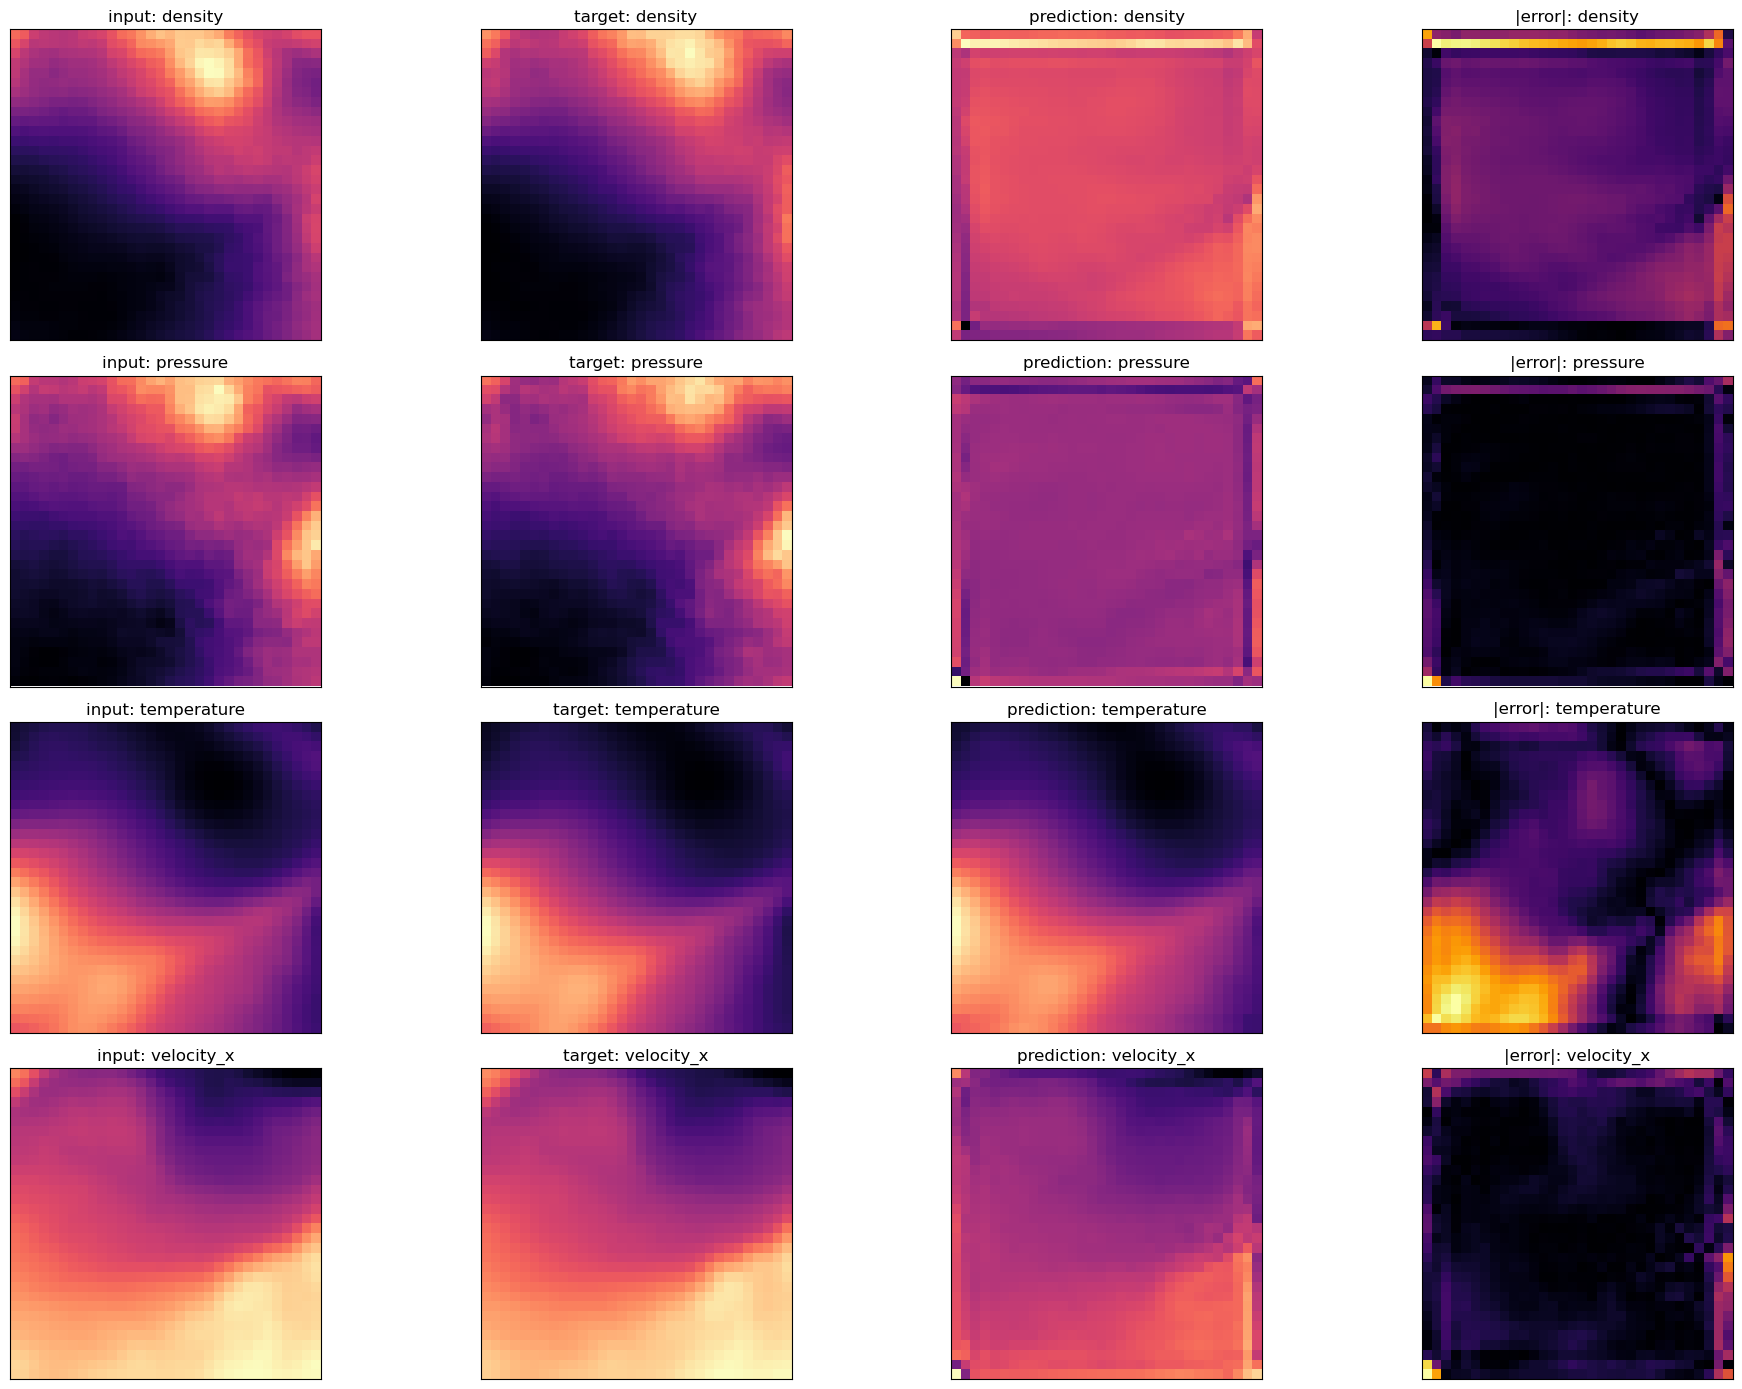

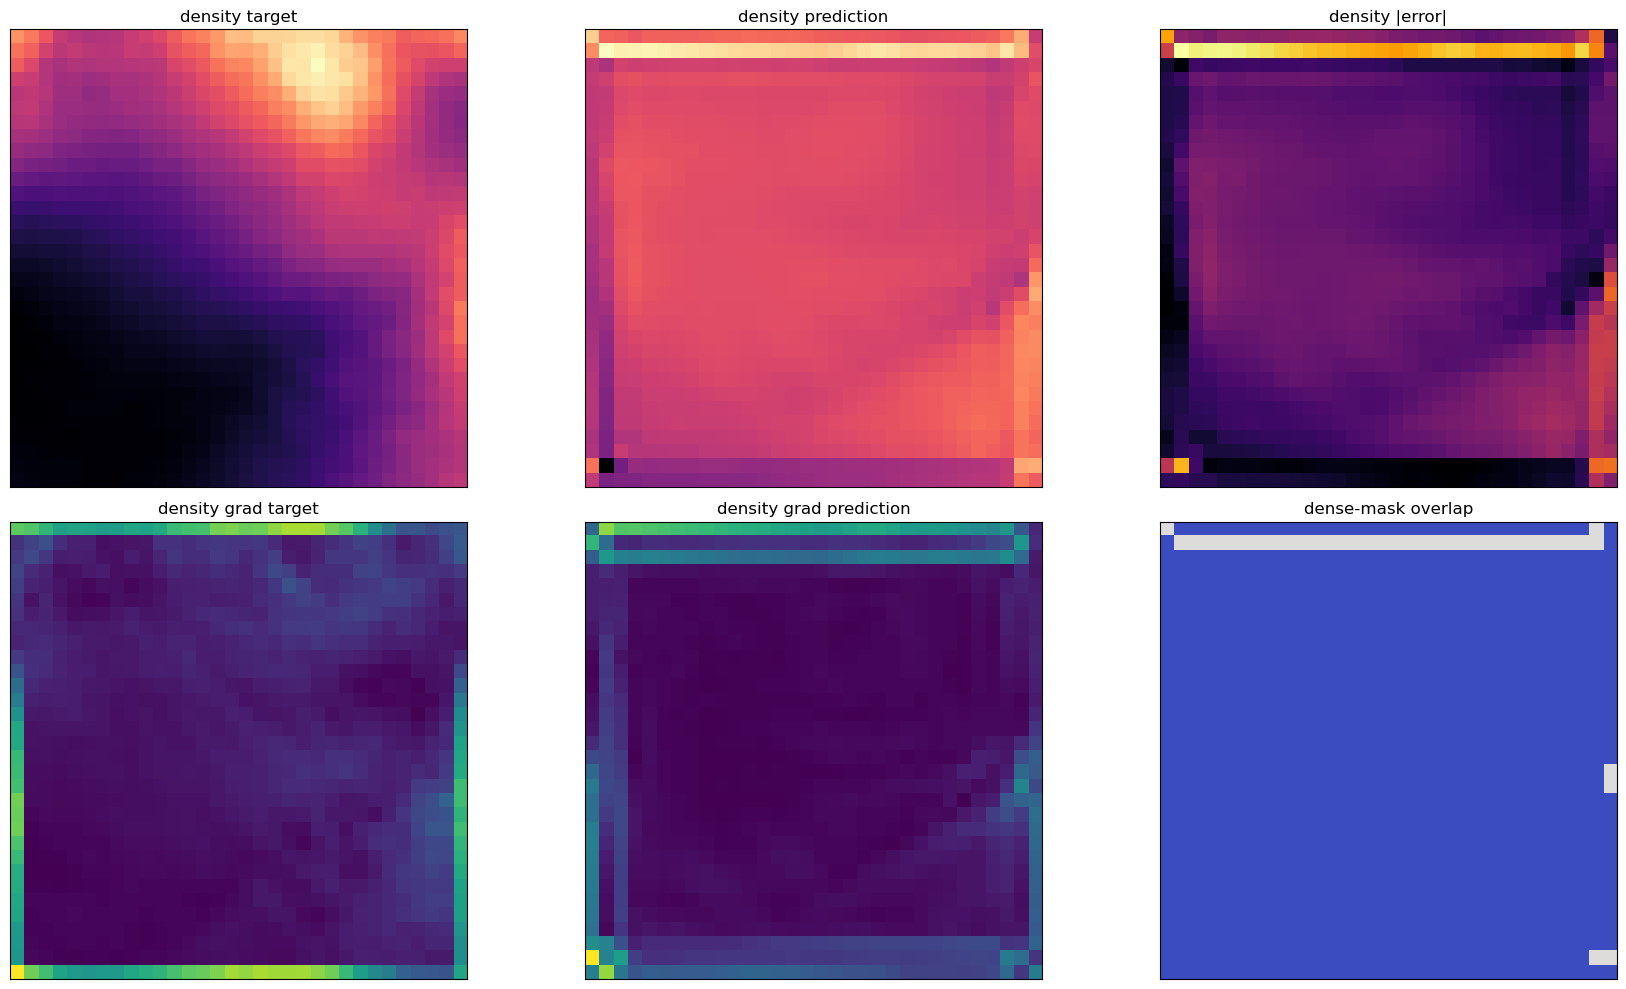

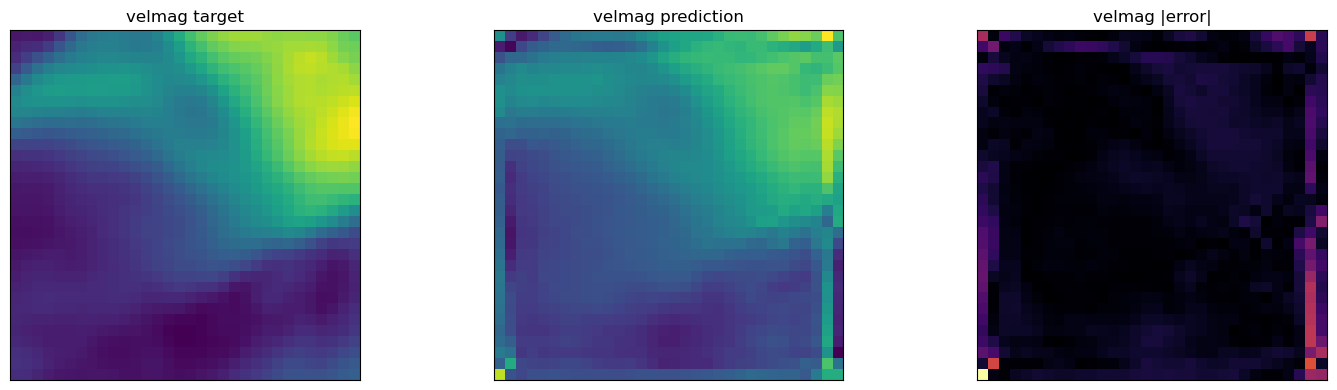

Prediction sample signature
{
  "rho0": 0.4449999928474426,
  "Z": 1.0,
  "T0": 1000.0,
  "input_time": 0.0,
  "output_time": 0.010204076766967773
}

Loss breakdown on displayed sample
{
  "global_mse": 33.045654296875,
  "density_mse": 0.6122457981109619,
  "dense_region_density": 1.1205644607543945,
  "density_gradient": 0.1946844756603241,
  "velocity_magnitude": 0.015312940813601017,
  "mass_consistency": 0.436159610748291,
  "total": 36.0438232421875
}

Evaluation metrics on displayed sample
{
  "mse_by_field": {
    "density": 0.6122457981109619,
    "pressure": 0.019572816789150238,
    "temperature": 197.58628845214844,
    "velocity_x": 0.023880936205387115,
    "velocity_y": 0.02067234180867672,
    "velocity_z": 0.011263594031333923
  },
  "rel_l2_by_field": {
    "density": 4.7589592933654785,
    "pressure": 3.068643808364868,
    "temperature": 0.03565847501158714,
    "velocity_x": 0.5043692588806152,
    "velocity_y": 0.4786839485168457,
    "velocity_z": 0.133719891309

In [ ]:
# [Cell 13] — Qualitative prediction visualization with structure-aware diagnostics
# -----------------------------------------------------------------------------
# PURPOSE
# Visualize predictions on the SAME sample used for inference and add
# diagnostics aligned with the new physics-aware loss:
#   - prediction triplets
#   - error maps
#   - dense-region masks
#   - density-gradient comparison
#   - velocity-magnitude comparison
# -----------------------------------------------------------------------------

@torch.no_grad()
def get_model_prediction(model: nn.Module, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    y_hat = model(x)
    return y_hat.squeeze(0).cpu()

def sample_signature(s):
    return {
        "rho0": float(s["rho0"]),
        "Z": float(s["Z"]),
        "T0": float(s["T0"]),
        "input_time": float(s["input_time"]),
        "output_time": float(s["output_time"]),
    }

def density_gradient_magnitude_4d(x: torch.Tensor) -> torch.Tensor:
    """
    x: [D, H, W]
    """
    gx = 0.5 * (torch.roll(x, -1, dims=0) - torch.roll(x, 1, dims=0))
    gy = 0.5 * (torch.roll(x, -1, dims=1) - torch.roll(x, 1, dims=1))
    gz = 0.5 * (torch.roll(x, -1, dims=2) - torch.roll(x, 1, dims=2))
    return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-12)

def dense_region_mask_single(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    """
    x: [C, D, H, W]
    returns mask over density field: [D, H, W]
    """
    density = x[FIELD_TO_INDEX["density"]]
    thresh = torch.quantile(density.reshape(-1), quantile)
    return density >= thresh

def plot_prediction_triplets(
    x: torch.Tensor,
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    fields: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (18, 14),
):
    x = x.cpu()
    y = y.cpu()
    y_hat = y_hat.cpu()

    if fields is None:
        fields = FIELD_NAMES

    z_slice = x.shape[1] // 2 if z_slice is None else z_slice
    idxs = [FIELD_TO_INDEX[f] for f in fields]

    fig, axs = plt.subplots(len(fields), 4, figsize=figsize)

    if len(fields) == 1:
        axs = np.expand_dims(axs, axis=0)

    for r, (idx, name) in enumerate(zip(idxs, fields)):
        xin = x[idx, z_slice].numpy()
        ytrue = y[idx, z_slice].numpy()
        ypred = y_hat[idx, z_slice].numpy()
        err = np.abs(ypred - ytrue)

        axs[r, 0].imshow(xin, cmap="magma")
        axs[r, 0].set_title(f"input: {name}")
        axs[r, 0].set_xticks([])
        axs[r, 0].set_yticks([])

        axs[r, 1].imshow(ytrue, cmap="magma")
        axs[r, 1].set_title(f"target: {name}")
        axs[r, 1].set_xticks([])
        axs[r, 1].set_yticks([])

        axs[r, 2].imshow(ypred, cmap="magma")
        axs[r, 2].set_title(f"prediction: {name}")
        axs[r, 2].set_xticks([])
        axs[r, 2].set_yticks([])

        axs[r, 3].imshow(err, cmap="inferno")
        axs[r, 3].set_title(f"|error|: {name}")
        axs[r, 3].set_xticks([])
        axs[r, 3].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_density_structure_diagnostics(
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    dense_quantile: float = 0.95,
    figsize: Tuple[int, int] = (18, 10),
):
    y = y.cpu()
    y_hat = y_hat.cpu()

    density_true = y[FIELD_TO_INDEX["density"]]
    density_pred = y_hat[FIELD_TO_INDEX["density"]]

    z_slice = density_true.shape[0] // 2 if z_slice is None else z_slice

    grad_true = density_gradient_magnitude_4d(density_true)
    grad_pred = density_gradient_magnitude_4d(density_pred)

    mask_true = dense_region_mask_single(y, quantile=dense_quantile).float()
    mask_pred = dense_region_mask_single(y_hat, quantile=dense_quantile).float()

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    axs[0, 0].imshow(density_true[z_slice].numpy(), cmap="magma")
    axs[0, 0].set_title("density target")
    axs[0, 0].set_xticks([])
    axs[0, 0].set_yticks([])

    axs[0, 1].imshow(density_pred[z_slice].numpy(), cmap="magma")
    axs[0, 1].set_title("density prediction")
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])

    axs[0, 2].imshow(torch.abs(density_pred[z_slice] - density_true[z_slice]).numpy(), cmap="inferno")
    axs[0, 2].set_title("density |error|")
    axs[0, 2].set_xticks([])
    axs[0, 2].set_yticks([])

    axs[1, 0].imshow(grad_true[z_slice].numpy(), cmap="viridis")
    axs[1, 0].set_title("density grad target")
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    axs[1, 1].imshow(grad_pred[z_slice].numpy(), cmap="viridis")
    axs[1, 1].set_title("density grad prediction")
    axs[1, 1].set_xticks([])
    axs[1, 1].set_yticks([])

    overlap = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_pred[z_slice].numpy()
    axs[1, 2].imshow(overlap, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 2].set_title("dense-mask overlap")
    axs[1, 2].set_xticks([])
    axs[1, 2].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_velocity_magnitude_diagnostics(
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (15, 4),
):
    y = y.cpu()
    y_hat = y_hat.cpu()

    vm_true = velocity_magnitude(y)
    vm_pred = velocity_magnitude(y_hat)

    z_slice = vm_true.shape[0] // 2 if z_slice is None else z_slice

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    axs[0].imshow(vm_true[z_slice].numpy(), cmap="viridis")
    axs[0].set_title("velmag target")
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    axs[1].imshow(vm_pred[z_slice].numpy(), cmap="viridis")
    axs[1].set_title("velmag prediction")
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    axs[2].imshow(torch.abs(vm_pred[z_slice] - vm_true[z_slice]).numpy(), cmap="inferno")
    axs[2].set_title("velmag |error|")
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def print_sample_prediction_summary(sample: Dict[str, Any], pred: torch.Tensor):
    breakdown = compute_loss_breakdown(
        sample["x"].unsqueeze(0).to(DEVICE),
        pred.unsqueeze(0).to(DEVICE),
        sample["y"].unsqueeze(0).to(DEVICE),
    )

    metrics = evaluate_batch_metrics(
        pred.unsqueeze(0).to(DEVICE),
        sample["y"].unsqueeze(0).to(DEVICE),
    )

    print("=" * 100)
    print("Prediction sample signature")
    print("=" * 100)
    print(json.dumps(sample_signature(sample), indent=2))

    print("\n" + "=" * 100)
    print("Loss breakdown on displayed sample")
    print("=" * 100)
    print(json.dumps({k: float(v) for k, v in breakdown.items()}, indent=2))

    print("\n" + "=" * 100)
    print("Evaluation metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(metrics, indent=2))

# -----------------------------------------------------------------------------
# Use ONE consistent sample
# -----------------------------------------------------------------------------
display_sample = sample0
pred = get_model_prediction(model, display_sample)

plot_prediction_triplets(
    display_sample["x"],
    display_sample["y"],
    pred,
    fields=["density", "pressure", "temperature", "velocity_x"],
    figsize=(20, 14),
)

plot_density_structure_diagnostics(
    display_sample["y"],
    pred,
    dense_quantile=0.95,
)

plot_velocity_magnitude_diagnostics(
    display_sample["y"],
    pred,
)

print_sample_prediction_summary(display_sample, pred)

In [ ]:
# [Cell 14] — Quantitative evaluation on a few batches
# -----------------------------------------------------------------------------

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, max_batches: int = 5) -> Dict[str, Any]:
    model.eval()

    global_mse_vals = []
    velmag_rel_vals = []

    mse_acc = {name: [] for name in FIELD_NAMES}
    rel_acc = {name: [] for name in FIELD_NAMES}

    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        y_hat = model(x)

        metrics = evaluate_batch_metrics(y_hat, y)
        global_mse_vals.append(metrics["global_mse"])
        velmag_rel_vals.append(metrics["velocity_magnitude_rel_l2"])

        for name in FIELD_NAMES:
            mse_acc[name].append(metrics["mse_by_field"][name])
            rel_acc[name].append(metrics["rel_l2_by_field"][name])

    out = {
        "global_mse_mean": float(np.mean(global_mse_vals)),
        "velocity_magnitude_rel_l2_mean": float(np.mean(velmag_rel_vals)),
        "mse_by_field_mean": {k: float(np.mean(v)) for k, v in mse_acc.items()},
        "rel_l2_by_field_mean": {k: float(np.mean(v)) for k, v in rel_acc.items()},
    }
    return out

eval_metrics = evaluate_model(model, canonical_eval_loader, max_batches=3)
display(Markdown("## Evaluation metrics"))
print(json.dumps(eval_metrics, indent=2))

## Evaluation metrics

{
  "global_mse_mean": 333.18582916259766,
  "velocity_magnitude_rel_l2_mean": 0.6226791044076284,
  "mse_by_field_mean": {
    "density": 3.2341105937957764,
    "pressure": 0.15982488666971525,
    "temperature": 1995.251988728841,
    "velocity_x": 0.21366598208745322,
    "velocity_y": 0.1590542048215866,
    "velocity_z": 0.0962108460565408
  },
  "rel_l2_by_field_mean": {
    "density": 1.5461336572964985,
    "pressure": 6.555351893107097,
    "temperature": 0.05961605409781138,
    "velocity_x": 1.065170665582021,
    "velocity_y": 0.8549244006474813,
    "velocity_z": 0.7052842875321707
  }
}


In [ ]:
# [Cell 15] — Dense-region audit and physically meaningful diagnostics
# -----------------------------------------------------------------------------

def dense_region_mask(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    if x.ndim == 4:
        density = x[FIELD_TO_INDEX["density"]]
        thresh = torch.quantile(density.reshape(-1), quantile)
        return density >= thresh

    density = x[:, FIELD_TO_INDEX["density"]]
    flat = density.reshape(density.shape[0], -1)
    thresh = torch.quantile(flat, quantile, dim=1, keepdim=True)
    thresh = thresh.view(-1, 1, 1, 1)
    return density >= thresh

@torch.no_grad()
def dense_region_iou(pred: torch.Tensor, truth: torch.Tensor, quantile: float = 0.95) -> float:
    pm = dense_region_mask(pred, quantile=quantile)
    tm = dense_region_mask(truth, quantile=quantile)
    inter = (pm & tm).float().sum()
    union = (pm | tm).float().sum() + 1e-12
    return float((inter / union).item())

@torch.no_grad()
def audit_dense_region_tracking(model: nn.Module, loader: DataLoader, max_batches: int = 3) -> Dict[str, float]:
    model.eval()
    vals = []

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        y_hat = model(x)
        vals.append(dense_region_iou(y_hat, y, quantile=0.95))

    return {"dense_region_iou_mean": float(np.mean(vals))}

dense_audit = audit_dense_region_tracking(model, canonical_eval_loader, max_batches=3)
display(Markdown("## Dense-region audit"))
print(json.dumps(dense_audit, indent=2))

## Dense-region audit

{
  "dense_region_iou_mean": 0.17424956957499185
}


In [ ]:
# [Cell 16] — Agent-facing summary object for this environment
# -----------------------------------------------------------------------------
# PURPOSE
# Create a compact summary that your broader orchestration system can consume.
# -----------------------------------------------------------------------------

def build_agent_environment_summary(
    sample: Dict[str, Any],
    eval_metrics: Dict[str, Any],
    dense_audit: Dict[str, float],
) -> Dict[str, Any]:
    pack = make_tgc_context_pack(sample)

    summary = {
        "environment_name": "turbulence_gravity_cooling",
        "task_type": "3D one-step physical field forecasting",
        "field_schema": FIELD_NAMES,
        "constant_scalars": pack["constant_scalars"],
        "boundary_conditions": pack["boundary_conditions"],
        "input_stats": pack["input_field_stats"],
        "model_eval": eval_metrics,
        "physics_audits": dense_audit,
        "scientific_interpretation": {
            "important_outputs": [
                "density",
                "temperature",
                "velocity magnitude",
                "dense-region structure",
            ],
            "agent_relevance": [
                "can reason over named physical variables",
                "can compare scalar thermodynamic fields and vector flow fields",
                "can audit dense-region preservation instead of generic pixel error only",
            ],
        },
    }
    return summary

agent_env_summary = build_agent_environment_summary(sample0, eval_metrics, dense_audit)
display(Markdown("## Agent environment summary"))
print(json.dumps(agent_env_summary, indent=2))

def sample_signature(s):
    return {
        "rho0": float(s["rho0"]),
        "Z": float(s["Z"]),
        "T0": float(s["T0"]),
        "input_time": float(s["input_time"]),
        "output_time": float(s["output_time"]),
    }

print("summary sample:", sample_signature(sample0))

## Agent environment summary

{
  "environment_name": "turbulence_gravity_cooling",
  "task_type": "3D one-step physical field forecasting",
  "field_schema": [
    "density",
    "pressure",
    "temperature",
    "velocity_x",
    "velocity_y",
    "velocity_z"
  ],
  "constant_scalars": {
    "rho0": 0.4449999928474426,
    "Z": 1.0,
    "T0": 1000.0
  },
  "boundary_conditions": [
    "OPEN"
  ],
  "input_stats": {
    "density": {
      "mean": 0.152433380484581,
      "std": 0.07528352737426758,
      "min": 0.0427430234849453,
      "max": 0.8871809840202332
    },
    "pressure": {
      "mean": 0.044727426022291183,
      "std": 0.012219073250889778,
      "min": 0.024690283462405205,
      "max": 0.13396218419075012
    },
    "temperature": {
      "mean": 371.64080810546875,
      "std": 102.73966979980469,
      "min": 166.423828125,
      "max": 677.279296875
    },
    "velocity_x": {
      "mean": -0.02110454812645912,
      "std": 0.312168151140213,
      "min": -0.8429051041603088,
      "max": 0.

In [ ]:
# [Cell 17] — Optional raw-file browser for quick scientific inspection
# -----------------------------------------------------------------------------

def inspect_raw_file(path: Path):
    with h5py.File(path, "r") as f:
        print("=" * 100)
        print(f"[RAW FILE] {path.name}")
        print("=" * 100)
        print("top-level keys:", list(f.keys()))
        print()

        if "t0_fields" in f:
            print("t0_fields:", list(f["t0_fields"].keys()))
            for k in f["t0_fields"].keys():
                print(f"  {k}: shape={f['t0_fields'][k].shape}")

        if "t1_fields" in f:
            print("\nt1_fields:", list(f["t1_fields"].keys()))
            for k in f["t1_fields"].keys():
                print(f"  {k}: shape={f['t1_fields'][k].shape}")

        if "boundary_conditions" in f:
            print("\nboundary_conditions:", list(f["boundary_conditions"].keys()))

if len(RAW_FILES) > 0:
    inspect_raw_file(RAW_FILES[0])
else:
    print("[INFO] No local raw HDF5 files available. Skipping raw-file inspection.")

[INFO] No local raw HDF5 files available. Skipping raw-file inspection.


In [ ]:
# [Cell 18] — Save a notebook report snapshot
# -----------------------------------------------------------------------------

report = {
    "metadata": META,
    "example_context_pack": context_pack,
    "evaluation": eval_metrics,
    "dense_audit": dense_audit,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "cache_info": {
        "cache_dir": str(CACHE_DIR.resolve()),
        "raw_h5_count": len(RAW_FILES),
        "first_batch_cache_exists": first_batch_cache_path().exists(),
        "sample0_cache_exists": sample0_cache_path().exists(),
        "canonical_dataset_cache_exists": canonical_dataset_cache_path().exists(),
    },
}

report_path = LOG_DIR / "tgc_notebook_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"[REPORT SAVED] {report_path}")

[REPORT SAVED] /home/b/bl/bluetopazzz/HybridNets/notebooks/logs/tgc_notebook_report.json


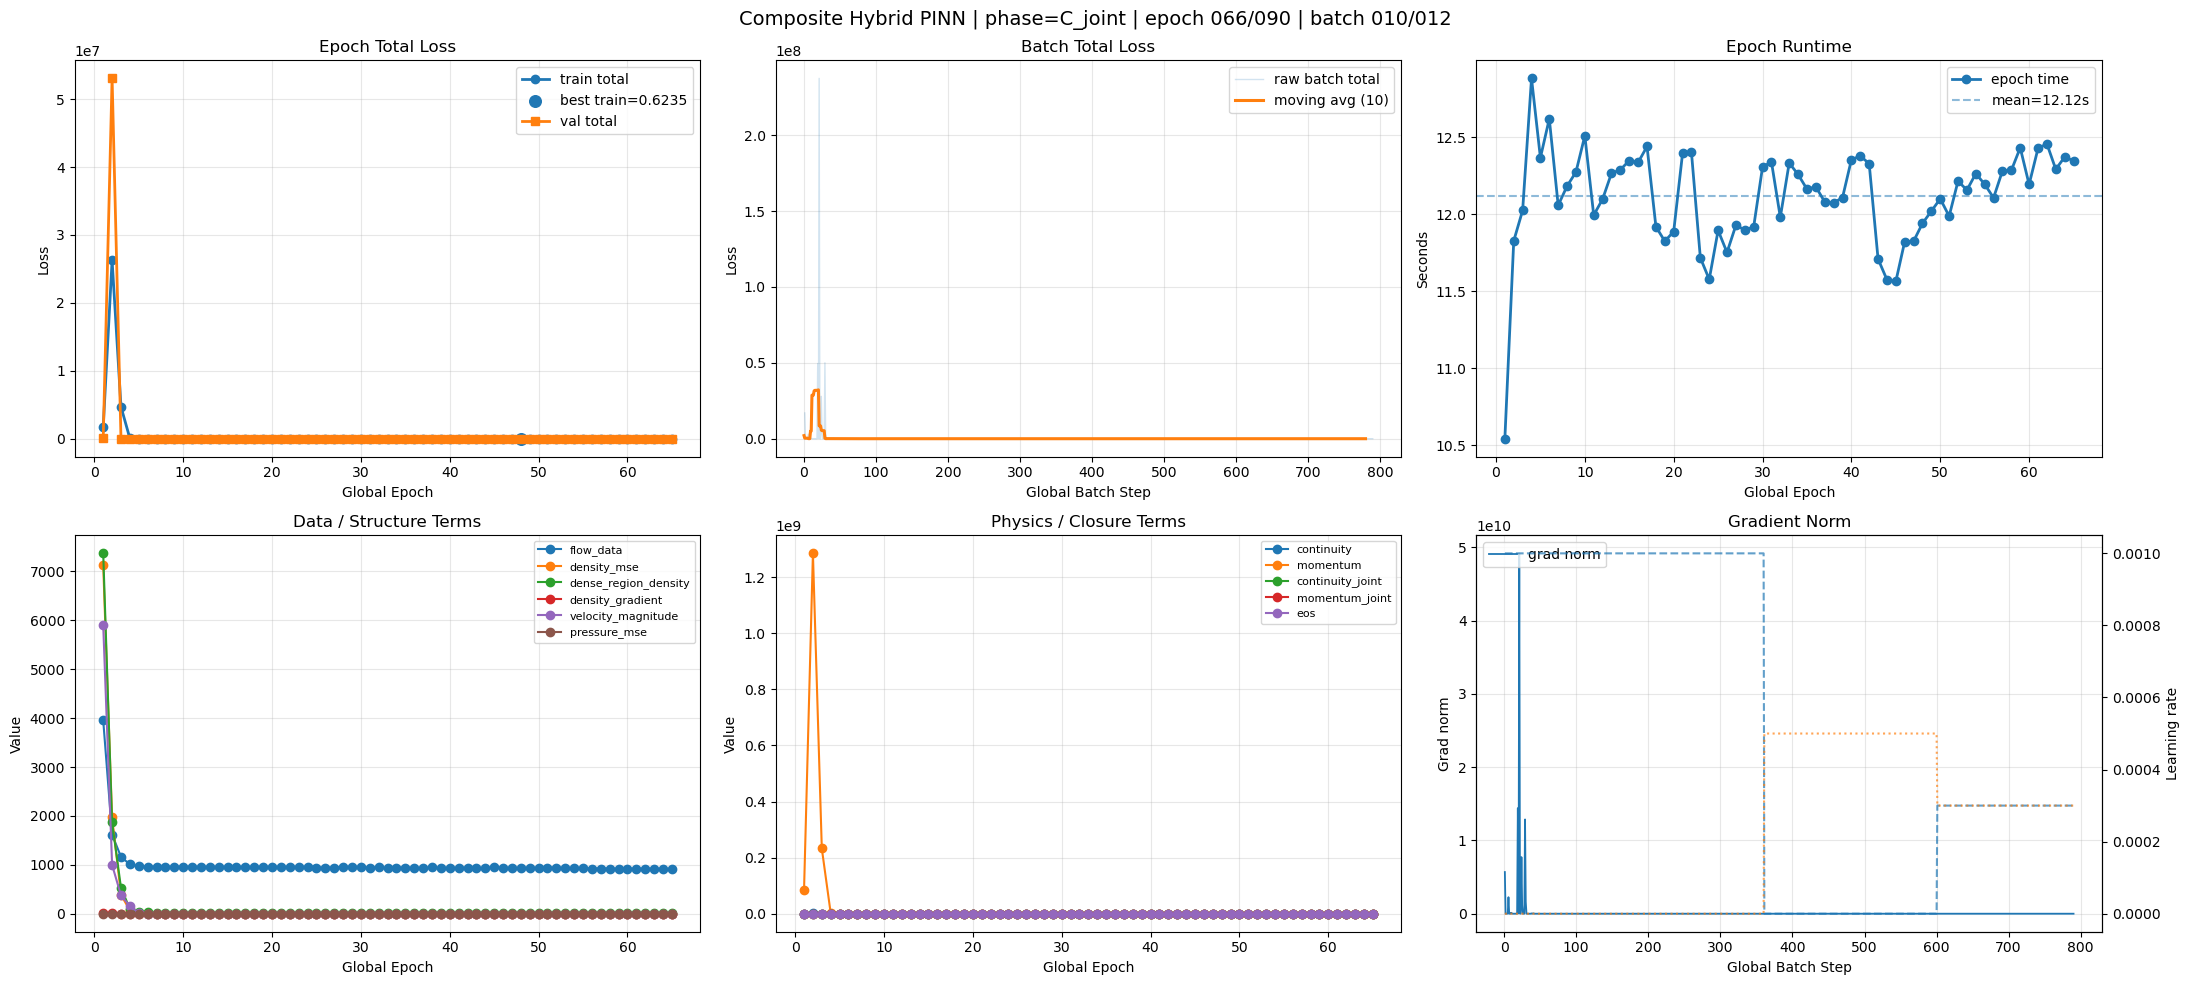

[COMPOSITE HYBRID LIVE] phase=C_joint | epoch 066/090 | batch 010/012 | elapsed 9.35s | running total 648.163198
last batch total loss   : 259.990112
last epoch train total  : 925.574292
best train total        : 0.623492
last epoch val total    : 441.353135
best val total          : 0.638165
mean epoch time         : 12.12s
rough ETA remaining     : 302.90s
skipped non-finite batches so far: 0

last batch breakdown:
  flow_data             : 116.629448
  density_mse           : 7.116305
  dense_region_density  : 135.436478
  density_gradient      : 0.308775
  velocity_magnitude    : 0.070214
  mass_consistency      : 0.000399
  continuity            : 1.154031
  momentum              : 103.924774
  pressure_mse          : 0.000056
  eos                   : 68.128357
  continuity_joint      : 1.154031
  momentum_joint        : 103.924927
  total                 : 259.990112
  eos_alpha             : 0.878460
  log_eos_alpha         : -0.129585


In [ ]:
# [DROP-IN REPLACEMENT NEW CELL] — Composite hybrid PINN with staged flow→pressure→joint training
# -----------------------------------------------------------------------------
# PURPOSE
# -------
# This cell replaces the earlier monolithic hybrid PINN with a mathematically
# structured composite model and a staged training procedure.
#
# CORE IDEA
# ---------
# Instead of forcing one shared network to learn all six output channels equally
# from the start, we use the factorization:
#
#   z_{t+dt} = H_\phi(x_t, c)
#   p_{t+dt} = Π_\psi(x_t, c, z_{t+dt})
#
# where:
#   z = [density, temperature, velocity_x, velocity_y, velocity_z]
#   p = pressure
#
# This means:
#   1. First learn the flow / thermodynamic backbone
#   2. Then learn pressure on top of that stable backbone
#   3. Then do a mild joint fine-tuning phase
#
# WHY THIS SHOULD WORK BETTER
# ---------------------------
# Earlier experiments showed:
#   - shared one-stage training could fit density/velocity well but miss pressure
#   - pressure-specialized training could fit pressure well but destroy flow
#
# That indicates gradient interference between tasks. This staged formulation
# reduces that interference by respecting the physics structure:
#
#   flow backbone first -> pressure closure second -> joint consistency last
#
# MODEL OVERVIEW
# --------------
# Inputs:
#   x_t: [B, 6, D, H, W]
#   constants: [B, 3] = [rho0, Z, T0]
#
# Outputs:
#   z_hat: [B, 5, D, H, W] for [rho, T, vx, vy, vz]
#   p_hat: [B, 1, D, H, W]
#   y_hat: [B, 6, D, H, W]
#
# TRAINING PHASES
# ---------------
# Phase A: Flow pretraining
#   Optimize density, temperature, velocity, dense regions, gradients,
#   continuity, and a light momentum residual.
#
# Phase B: Pressure fitting
#   Freeze the flow backbone and train pressure using pressure data loss and a
#   light EOS regularizer in log space.
#
# Phase C: Joint fine-tuning
#   Unfreeze everything and optimize a mild coupled objective with scheduled
#   pressure / EOS weights so pressure does not hijack the trunk.
#
# NOTE
# ----
# This cell assumes the notebook already has:
#   - FIELD_NAMES
#   - FIELD_TO_INDEX
#   - ensure_float32
#   - velocity_magnitude
#   - dense_region_iou
#   - plot_prediction_triplets
#   - plot_density_structure_diagnostics
#   - plot_velocity_magnitude_diagnostics
#   - sample_signature
#   - canonical_train_loader
#   - canonical_eval_loader
#   - sample0
#   - DEVICE
#   - LOG_DIR
#   - report_path
# -----------------------------------------------------------------------------

import copy
import json
import math
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display, Markdown

import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------------------------------------------------------
# Numerical / physics helpers
# -----------------------------------------------------------------------------

def fd_centered_3d(x: torch.Tensor, dim: int, spacing: float = 1.0) -> torch.Tensor:
    """
    Centered finite difference using roll-based periodic stencil.

    Args:
        x: [B, D, H, W]
        dim: spatial axis in x, one of {1,2,3}
        spacing: grid spacing
    """
    return (torch.roll(x, shifts=-1, dims=dim) - torch.roll(x, shifts=1, dims=dim)) / (2.0 * spacing)

def divergence_3d(
    fx: torch.Tensor,
    fy: torch.Tensor,
    fz: torch.Tensor,
    dx: float = 1.0,
    dy: float = 1.0,
    dz: float = 1.0,
) -> torch.Tensor:
    """
    Divergence of a vector field with components [B, D, H, W].
    """
    return (
        fd_centered_3d(fx, dim=1, spacing=dx)
        + fd_centered_3d(fy, dim=2, spacing=dy)
        + fd_centered_3d(fz, dim=3, spacing=dz)
    )

def density_gradient_magnitude_batch(rho: torch.Tensor) -> torch.Tensor:
    """
    rho: [B, D, H, W]
    """
    gx = fd_centered_3d(rho, dim=1)
    gy = fd_centered_3d(rho, dim=2)
    gz = fd_centered_3d(rho, dim=3)
    return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-12)

def dense_region_mask_batch(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    """
    x: [B, C, D, H, W]
    Returns density mask [B, D, H, W]
    """
    density = x[:, FIELD_TO_INDEX["density"]]
    flat = density.reshape(density.shape[0], -1)
    thresh = torch.quantile(flat, quantile, dim=1, keepdim=True)
    thresh = thresh.view(-1, 1, 1, 1)
    return density >= thresh

def safe_positive(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return torch.clamp(x, min=eps)

def safe_log_positive(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return torch.log(torch.clamp(x, min=eps))

def grad_norm_of_model(model: nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            if torch.isfinite(g).all():
                total += float(torch.sum(g * g).item())
    return math.sqrt(total) if total > 0 else 0.0

def sanitize_gradients_(model: nn.Module) -> None:
    with torch.no_grad():
        for p in model.parameters():
            if p.grad is not None:
                p.grad = torch.nan_to_num(p.grad, nan=0.0, posinf=0.0, neginf=0.0)

def model_parameters_are_finite(model: nn.Module) -> bool:
    return all(torch.isfinite(p).all() for p in model.parameters())

def moving_average_np(x, window: int = 20):
    vals = np.asarray([v for v in x if np.isfinite(v)], dtype=float)
    if len(vals) == 0:
        return np.array([])
    window = max(1, min(window, len(vals)))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(vals, kernel, mode="valid")

# -----------------------------------------------------------------------------
# Channel packing helpers
# -----------------------------------------------------------------------------

FLOW_CHANNEL_ORDER = ["density", "temperature", "velocity_x", "velocity_y", "velocity_z"]

def unpack_state_channels(y: torch.Tensor) -> Dict[str, torch.Tensor]:
    """
    y: [B, 6, D, H, W]
    """
    return {
        "density": y[:, FIELD_TO_INDEX["density"]],
        "pressure": y[:, FIELD_TO_INDEX["pressure"]],
        "temperature": y[:, FIELD_TO_INDEX["temperature"]],
        "velocity_x": y[:, FIELD_TO_INDEX["velocity_x"]],
        "velocity_y": y[:, FIELD_TO_INDEX["velocity_y"]],
        "velocity_z": y[:, FIELD_TO_INDEX["velocity_z"]],
    }

def unpack_flow_channels(z: torch.Tensor) -> Dict[str, torch.Tensor]:
    """
    z: [B, 5, D, H, W] in FLOW_CHANNEL_ORDER
    """
    return {
        "density": z[:, 0],
        "temperature": z[:, 1],
        "velocity_x": z[:, 2],
        "velocity_y": z[:, 3],
        "velocity_z": z[:, 4],
    }

def assemble_full_state_from_flow_and_pressure(
    z_hat: torch.Tensor,
    p_hat: torch.Tensor,
) -> torch.Tensor:
    """
    z_hat: [B, 5, D, H, W] = [density, temperature, vx, vy, vz]
    p_hat: [B, 1, D, H, W]
    return y_hat: [B, 6, D, H, W] in canonical order
    """
    density = z_hat[:, 0:1]
    temperature = z_hat[:, 1:2]
    vx = z_hat[:, 2:3]
    vy = z_hat[:, 3:4]
    vz = z_hat[:, 4:5]
    return torch.cat([density, p_hat, temperature, vx, vy, vz], dim=1)

# -----------------------------------------------------------------------------
# Model components
# -----------------------------------------------------------------------------

class ResidualConvBlock3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels),
            nn.GELU(),
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.gelu(x + self.block(x))

class FlowBackbone3D(nn.Module):
    """
    Learns the flow / thermodynamic backbone:
      z_hat = [density, temperature, velocity_x, velocity_y, velocity_z]
    """
    def __init__(self, in_ch: int = 6, cond_ch: int = 3, hidden: int = 48, depth: int = 5):
        super().__init__()
        total_in = in_ch + cond_ch
        self.in_proj = nn.Conv3d(total_in, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualConvBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, 5, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, constants: torch.Tensor) -> torch.Tensor:
        B, _, D, H, W = x.shape
        c = constants[:, :, None, None, None].expand(B, 3, D, H, W)
        h = torch.cat([x, c], dim=1)
        h = F.gelu(self.in_proj(h))
        for blk in self.blocks:
            h = blk(h)

        delta = self.out_proj(h)

        density_t = x[:, 0:1]
        temperature_t = x[:, 2:3]
        vx_t = x[:, 3:4]
        vy_t = x[:, 4:5]
        vz_t = x[:, 5:6]

        density_pred = density_t + delta[:, 0:1]
        temperature_pred = temperature_t + delta[:, 1:2]
        vx_pred = vx_t + delta[:, 2:3]
        vy_pred = vy_t + delta[:, 3:4]
        vz_pred = vz_t + delta[:, 4:5]

        return torch.cat([density_pred, temperature_pred, vx_pred, vy_pred, vz_pred], dim=1)

class PressureHead3D(nn.Module):
    """
    Learns pressure from:
      - original input state x_t
      - predicted backbone state z_hat
      - constants c

    Pressure is represented in log space:
      log p_{t+dt} = log p_t + delta_log_p
    """
    def __init__(
        self,
        x_in_ch: int = 6,
        z_in_ch: int = 5,
        cond_ch: int = 3,
        hidden: int = 32,
        depth: int = 3,
        pressure_delta_scale: float = 0.10,
        logp_min: float = -10.0,
        logp_max: float = 10.0,
    ):
        super().__init__()
        total_in = x_in_ch + z_in_ch + cond_ch
        self.in_proj = nn.Conv3d(total_in, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualConvBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, 1, kernel_size=3, padding=1)

        self.pressure_delta_scale = float(pressure_delta_scale)
        self.logp_min = float(logp_min)
        self.logp_max = float(logp_max)

    def forward(self, x: torch.Tensor, constants: torch.Tensor, z_hat: torch.Tensor, pressure_eps: float = 1e-8) -> torch.Tensor:
        B, _, D, H, W = x.shape
        c = constants[:, :, None, None, None].expand(B, 3, D, H, W)
        h = torch.cat([x, z_hat, c], dim=1)
        h = F.gelu(self.in_proj(h))
        for blk in self.blocks:
            h = blk(h)

        raw_delta_logp = self.out_proj(h)
        delta_logp = self.pressure_delta_scale * torch.tanh(raw_delta_logp)

        pressure_t = x[:, 1:2]
        logp_t = safe_log_positive(pressure_t, eps=pressure_eps)
        logp_pred = torch.clamp(logp_t + delta_logp, min=self.logp_min, max=self.logp_max)
        p_hat = torch.exp(logp_pred)
        return p_hat

class CompositeHybridPINN3D(nn.Module):
    """
    Composite model:
      flow backbone first, pressure closure second
    """
    def __init__(
        self,
        flow_hidden: int = 48,
        flow_depth: int = 5,
        pressure_hidden: int = 32,
        pressure_depth: int = 3,
        pressure_delta_scale: float = 0.10,
        logp_min: float = -10.0,
        logp_max: float = 10.0,
    ):
        super().__init__()
        self.flow_backbone = FlowBackbone3D(hidden=flow_hidden, depth=flow_depth)
        self.pressure_head = PressureHead3D(
            hidden=pressure_hidden,
            depth=pressure_depth,
            pressure_delta_scale=pressure_delta_scale,
            logp_min=logp_min,
            logp_max=logp_max,
        )
        self.log_eos_alpha = nn.Parameter(torch.tensor(0.0))

    @property
    def eos_alpha(self) -> torch.Tensor:
        return torch.exp(self.log_eos_alpha)

    def forward(self, x: torch.Tensor, constants: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        z_hat = self.flow_backbone(x, constants)
        p_hat = self.pressure_head(x, constants, z_hat)
        y_hat = assemble_full_state_from_flow_and_pressure(z_hat, p_hat)
        return z_hat, p_hat, y_hat

# -----------------------------------------------------------------------------
# Loss decomposition
# -----------------------------------------------------------------------------

def compute_flow_loss_terms(
    x: torch.Tensor,
    z_hat: torch.Tensor,
    y_true: torch.Tensor,
    dt: torch.Tensor,
    dense_quantile: float = 0.95,
    eps: float = 1e-8,
) -> Dict[str, torch.Tensor]:
    """
    Flow / thermodynamic terms for Phase A and joint training.
    """
    B = x.shape[0]
    dt = dt.view(B, 1, 1, 1)

    pred = unpack_flow_channels(z_hat)
    true = unpack_state_channels(y_true)
    xch = unpack_state_channels(x)

    rho_t = xch["density"]
    vx_t = xch["velocity_x"]
    vy_t = xch["velocity_y"]
    vz_t = xch["velocity_z"]

    rho_p_raw = pred["density"]
    T_p_raw = pred["temperature"]
    vx_p = pred["velocity_x"]
    vy_p = pred["velocity_y"]
    vz_p = pred["velocity_z"]

    rho_y = true["density"]
    T_y = true["temperature"]
    vx_y = true["velocity_x"]
    vy_y = true["velocity_y"]
    vz_y = true["velocity_z"]

    rho_p = safe_positive(rho_p_raw, eps=eps)

    flow_data = (
        F.mse_loss(rho_p_raw, rho_y)
        + F.mse_loss(T_p_raw, T_y)
        + F.mse_loss(vx_p, vx_y)
        + F.mse_loss(vy_p, vy_y)
        + F.mse_loss(vz_p, vz_y)
    ) / 5.0

    density_mse = F.mse_loss(rho_p_raw, rho_y)

    # Dense-region mask built from true full state
    dense_mask = dense_region_mask_batch(y_true, quantile=dense_quantile).float()
    dense_region_density = ((rho_p_raw - rho_y) ** 2 * dense_mask).sum() / (dense_mask.sum() + 1e-12)

    grad_rho_p = density_gradient_magnitude_batch(rho_p_raw)
    grad_rho_y = density_gradient_magnitude_batch(rho_y)
    density_gradient = F.l1_loss(grad_rho_p, grad_rho_y)

    velmag_p = torch.sqrt(vx_p**2 + vy_p**2 + vz_p**2 + 1e-12)
    velmag_y = torch.sqrt(vx_y**2 + vy_y**2 + vz_y**2 + 1e-12)
    velocity_magnitude = F.mse_loss(velmag_p, velmag_y)

    mass_hat = rho_p_raw.mean(dim=(1, 2, 3))
    mass_true = rho_y.mean(dim=(1, 2, 3))
    mass_consistency = F.mse_loss(mass_hat, mass_true)

    # Continuity residual
    drho_dt = (rho_p - rho_t) / dt
    cont_flux_x = rho_p * vx_p
    cont_flux_y = rho_p * vy_p
    cont_flux_z = rho_p * vz_p
    continuity_residual = drho_dt + divergence_3d(cont_flux_x, cont_flux_y, cont_flux_z)
    continuity = torch.mean(continuity_residual ** 2)

    # Reduced momentum using pressure from input during Phase A
    p_ref = safe_positive(xch["pressure"], eps=eps)

    momx_t = rho_t * vx_t
    momy_t = rho_t * vy_t
    momz_t = rho_t * vz_t

    momx_p = rho_p * vx_p
    momy_p = rho_p * vy_p
    momz_p = rho_p * vz_p

    dmomx_dt = (momx_p - momx_t) / dt
    dmomy_dt = (momy_p - momy_t) / dt
    dmomz_dt = (momz_p - momz_t) / dt

    div_momx = divergence_3d(rho_p * vx_p * vx_p, rho_p * vx_p * vy_p, rho_p * vx_p * vz_p)
    div_momy = divergence_3d(rho_p * vy_p * vx_p, rho_p * vy_p * vy_p, rho_p * vy_p * vz_p)
    div_momz = divergence_3d(rho_p * vz_p * vx_p, rho_p * vz_p * vy_p, rho_p * vz_p * vz_p)

    dp_dx = fd_centered_3d(p_ref, dim=1)
    dp_dy = fd_centered_3d(p_ref, dim=2)
    dp_dz = fd_centered_3d(p_ref, dim=3)

    momentum_x = torch.mean((dmomx_dt + div_momx + dp_dx) ** 2)
    momentum_y = torch.mean((dmomy_dt + div_momy + dp_dy) ** 2)
    momentum_z = torch.mean((dmomz_dt + div_momz + dp_dz) ** 2)
    momentum = (momentum_x + momentum_y + momentum_z) / 3.0

    return {
        "flow_data": flow_data,
        "density_mse": density_mse,
        "dense_region_density": dense_region_density,
        "density_gradient": density_gradient,
        "velocity_magnitude": velocity_magnitude,
        "mass_consistency": mass_consistency,
        "continuity": continuity,
        "momentum": momentum,
    }

def compute_pressure_loss_terms(
    model: CompositeHybridPINN3D,
    x: torch.Tensor,
    z_hat: torch.Tensor,
    p_hat: torch.Tensor,
    y_true: torch.Tensor,
    eps: float = 1e-8,
) -> Dict[str, torch.Tensor]:
    """
    Pressure-specific and EOS terms for Phase B / C.
    """
    true = unpack_state_channels(y_true)
    pred_flow = unpack_flow_channels(z_hat)

    p_true = true["pressure"]
    p_pred_raw = p_hat[:, 0]

    rho_pred = safe_positive(pred_flow["density"], eps=eps)
    T_pred = safe_positive(pred_flow["temperature"], eps=eps)
    p_pred = safe_positive(p_pred_raw, eps=eps)

    pressure_mse = F.mse_loss(p_pred_raw, p_true)

    log_p_pred = safe_log_positive(p_pred, eps=eps)
    log_rho_pred = safe_log_positive(rho_pred, eps=eps)
    log_T_pred = safe_log_positive(T_pred, eps=eps)

    eos = torch.mean((log_p_pred - (model.log_eos_alpha + log_rho_pred + log_T_pred)) ** 2)

    return {
        "pressure_mse": pressure_mse,
        "eos": eos,
    }

def compute_joint_physics_terms(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    dt: torch.Tensor,
    eps: float = 1e-8,
) -> Dict[str, torch.Tensor]:
    """
    Full continuity / momentum using predicted pressure for Phase C.
    """
    B = x.shape[0]
    dt = dt.view(B, 1, 1, 1)

    xch = unpack_state_channels(x)
    ych = unpack_state_channels(y_hat)

    rho_t = xch["density"]
    vx_t = xch["velocity_x"]
    vy_t = xch["velocity_y"]
    vz_t = xch["velocity_z"]

    rho_p = safe_positive(ych["density"], eps=eps)
    p_p = safe_positive(ych["pressure"], eps=eps)
    vx_p = ych["velocity_x"]
    vy_p = ych["velocity_y"]
    vz_p = ych["velocity_z"]

    drho_dt = (rho_p - rho_t) / dt
    cont_flux_x = rho_p * vx_p
    cont_flux_y = rho_p * vy_p
    cont_flux_z = rho_p * vz_p
    continuity_residual = drho_dt + divergence_3d(cont_flux_x, cont_flux_y, cont_flux_z)
    continuity = torch.mean(continuity_residual ** 2)

    momx_t = rho_t * vx_t
    momy_t = rho_t * vy_t
    momz_t = rho_t * vz_t

    momx_p = rho_p * vx_p
    momy_p = rho_p * vy_p
    momz_p = rho_p * vz_p

    dmomx_dt = (momx_p - momx_t) / dt
    dmomy_dt = (momy_p - momy_t) / dt
    dmomz_dt = (momz_p - momz_t) / dt

    div_momx = divergence_3d(rho_p * vx_p * vx_p, rho_p * vx_p * vy_p, rho_p * vx_p * vz_p)
    div_momy = divergence_3d(rho_p * vy_p * vx_p, rho_p * vy_p * vy_p, rho_p * vy_p * vz_p)
    div_momz = divergence_3d(rho_p * vz_p * vx_p, rho_p * vz_p * vy_p, rho_p * vz_p * vz_p)

    dp_dx = fd_centered_3d(p_p, dim=1)
    dp_dy = fd_centered_3d(p_p, dim=2)
    dp_dz = fd_centered_3d(p_p, dim=3)

    momentum_x = torch.mean((dmomx_dt + div_momx + dp_dx) ** 2)
    momentum_y = torch.mean((dmomy_dt + div_momy + dp_dy) ** 2)
    momentum_z = torch.mean((dmomz_dt + div_momz + dp_dz) ** 2)
    momentum = (momentum_x + momentum_y + momentum_z) / 3.0

    return {
        "continuity_joint": continuity,
        "momentum_joint": momentum,
    }

# -----------------------------------------------------------------------------
# Phase schedules
# -----------------------------------------------------------------------------

def get_phase_c_schedule(epoch: int, total_epochs: int) -> Dict[str, float]:
    """
    Smooth ramp for pressure/EOS during joint fine-tuning.
    """
    if total_epochs <= 1:
        s = 1.0
    else:
        s = epoch / float(total_epochs - 1)

    def ramp(x, start, end, max_val):
        if x < start:
            return 0.0
        if x >= end:
            return max_val
        return max_val * (x - start) / max(1e-12, end - start)

    return {
        "pressure": ramp(s, 0.20, 0.70, 0.30),
        "eos": ramp(s, 0.35, 0.75, 0.01),
        "continuity_joint": ramp(s, 0.00, 0.40, 0.15),
        "momentum_joint": ramp(s, 0.10, 0.50, 0.03),
    }

PHASE_A_WEIGHTS = {
    "flow_data": 1.0,
    "density_mse": 0.75,
    "dense_region_density": 1.00,
    "density_gradient": 0.35,
    "velocity_magnitude": 0.50,
    "mass_consistency": 0.10,
    "continuity": 0.20,
    "momentum": 0.02,
}

PHASE_B_WEIGHTS = {
    "pressure_mse": 1.0,
    "eos": 0.01,
}

PHASE_C_BASE_WEIGHTS = {
    "flow_data": 1.0,
    "density_mse": 0.75,
    "dense_region_density": 1.00,
    "density_gradient": 0.35,
    "velocity_magnitude": 0.50,
    "mass_consistency": 0.10,
}

# -----------------------------------------------------------------------------
# Phase control
# -----------------------------------------------------------------------------

def set_phase_trainability(model: CompositeHybridPINN3D, phase_name: str) -> None:
    if phase_name == "A_flow":
        for p in model.flow_backbone.parameters():
            p.requires_grad = True
        for p in model.pressure_head.parameters():
            p.requires_grad = False
        model.log_eos_alpha.requires_grad = False

    elif phase_name == "B_pressure":
        for p in model.flow_backbone.parameters():
            p.requires_grad = False
        for p in model.pressure_head.parameters():
            p.requires_grad = True
        model.log_eos_alpha.requires_grad = True

    elif phase_name == "C_joint":
        for p in model.flow_backbone.parameters():
            p.requires_grad = True
        for p in model.pressure_head.parameters():
            p.requires_grad = True
        model.log_eos_alpha.requires_grad = True
    else:
        raise ValueError(f"Unknown phase_name: {phase_name}")

def build_optimizer_for_phase(
    model: CompositeHybridPINN3D,
    phase_name: str,
    lr_flow: float,
    lr_pressure: float,
) -> torch.optim.Optimizer:
    params = []

    if phase_name == "A_flow":
        params.append({"params": [p for p in model.flow_backbone.parameters() if p.requires_grad], "lr": lr_flow})

    elif phase_name == "B_pressure":
        params.append({"params": [p for p in model.pressure_head.parameters() if p.requires_grad], "lr": lr_pressure})
        if model.log_eos_alpha.requires_grad:
            params.append({"params": [model.log_eos_alpha], "lr": lr_pressure})

    elif phase_name == "C_joint":
        params.append({"params": [p for p in model.flow_backbone.parameters() if p.requires_grad], "lr": lr_flow})
        params.append({"params": [p for p in model.pressure_head.parameters() if p.requires_grad], "lr": lr_pressure})
        if model.log_eos_alpha.requires_grad:
            params.append({"params": [model.log_eos_alpha], "lr": lr_pressure})
    else:
        raise ValueError(f"Unknown phase_name: {phase_name}")

    return torch.optim.Adam(params)

# -----------------------------------------------------------------------------
# History container
# -----------------------------------------------------------------------------

@dataclass
class CompositeHybridHistory:
    phase_names: List[str] = field(default_factory=list)
    epoch_index_global: List[int] = field(default_factory=list)
    train_total_loss: List[float] = field(default_factory=list)
    val_total_loss: List[float] = field(default_factory=list)
    epoch_time_sec: List[float] = field(default_factory=list)

    batch_total_loss: List[float] = field(default_factory=list)
    batch_step: List[int] = field(default_factory=list)
    grad_norm: List[float] = field(default_factory=list)
    learning_rate_flow: List[float] = field(default_factory=list)
    learning_rate_pressure: List[float] = field(default_factory=list)
    skipped_batches: List[int] = field(default_factory=list)

    epoch_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "flow_data": [],
        "density_mse": [],
        "dense_region_density": [],
        "density_gradient": [],
        "velocity_magnitude": [],
        "mass_consistency": [],
        "continuity": [],
        "momentum": [],
        "pressure_mse": [],
        "eos": [],
        "continuity_joint": [],
        "momentum_joint": [],
    })
    last_batch_breakdown: Dict[str, float] = field(default_factory=dict)

# -----------------------------------------------------------------------------
# Loss assembly by phase
# -----------------------------------------------------------------------------

def compute_phase_loss(
    model: CompositeHybridPINN3D,
    phase_name: str,
    epoch_in_phase: int,
    total_phase_epochs: int,
    x: torch.Tensor,
    constants: torch.Tensor,
    y: torch.Tensor,
    dt: torch.Tensor,
) -> Tuple[torch.Tensor, Dict[str, float], torch.Tensor]:
    """
    Returns:
      total_loss, breakdown_dict, y_hat
    """
    z_hat, p_hat, y_hat = model(x, constants)

    flow_terms = compute_flow_loss_terms(x, z_hat, y, dt)
    pressure_terms = compute_pressure_loss_terms(model, x, z_hat, p_hat, y)

    breakdown_tensors: Dict[str, torch.Tensor] = {}
    breakdown_tensors.update(flow_terms)
    breakdown_tensors.update(pressure_terms)

    if phase_name == "A_flow":
        total = (
            PHASE_A_WEIGHTS["flow_data"] * flow_terms["flow_data"]
            + PHASE_A_WEIGHTS["density_mse"] * flow_terms["density_mse"]
            + PHASE_A_WEIGHTS["dense_region_density"] * flow_terms["dense_region_density"]
            + PHASE_A_WEIGHTS["density_gradient"] * flow_terms["density_gradient"]
            + PHASE_A_WEIGHTS["velocity_magnitude"] * flow_terms["velocity_magnitude"]
            + PHASE_A_WEIGHTS["mass_consistency"] * flow_terms["mass_consistency"]
            + PHASE_A_WEIGHTS["continuity"] * flow_terms["continuity"]
            + PHASE_A_WEIGHTS["momentum"] * flow_terms["momentum"]
        )

    elif phase_name == "B_pressure":
        total = (
            PHASE_B_WEIGHTS["pressure_mse"] * pressure_terms["pressure_mse"]
            + PHASE_B_WEIGHTS["eos"] * pressure_terms["eos"]
        )

    elif phase_name == "C_joint":
        joint_terms = compute_joint_physics_terms(x, y_hat, dt)
        breakdown_tensors.update(joint_terms)

        sched = get_phase_c_schedule(epoch_in_phase, total_phase_epochs)
        total = (
            PHASE_C_BASE_WEIGHTS["flow_data"] * flow_terms["flow_data"]
            + PHASE_C_BASE_WEIGHTS["density_mse"] * flow_terms["density_mse"]
            + PHASE_C_BASE_WEIGHTS["dense_region_density"] * flow_terms["dense_region_density"]
            + PHASE_C_BASE_WEIGHTS["density_gradient"] * flow_terms["density_gradient"]
            + PHASE_C_BASE_WEIGHTS["velocity_magnitude"] * flow_terms["velocity_magnitude"]
            + PHASE_C_BASE_WEIGHTS["mass_consistency"] * flow_terms["mass_consistency"]
            + sched["pressure"] * pressure_terms["pressure_mse"]
            + sched["eos"] * pressure_terms["eos"]
            + sched["continuity_joint"] * joint_terms["continuity_joint"]
            + sched["momentum_joint"] * joint_terms["momentum_joint"]
        )
    else:
        raise ValueError(f"Unknown phase_name: {phase_name}")

    breakdown = {k: float(v.detach().item()) for k, v in breakdown_tensors.items()}
    breakdown["total"] = float(total.detach().item())
    breakdown["eos_alpha"] = float(model.eos_alpha.detach().item())
    breakdown["log_eos_alpha"] = float(model.log_eos_alpha.detach().item())

    return total, breakdown, y_hat

# -----------------------------------------------------------------------------
# Evaluation
# -----------------------------------------------------------------------------

@torch.no_grad()
def evaluate_composite_hybrid_loader(
    model: CompositeHybridPINN3D,
    loader: torch.utils.data.DataLoader,
    max_batches: Optional[int] = 5,
) -> Dict[str, Any]:
    model.eval()

    total_losses = []
    mse_acc = {name: [] for name in FIELD_NAMES}
    rel_acc = {name: [] for name in FIELD_NAMES}
    velmag_rel_vals = []
    pressure_mse_vals = []
    eos_vals = []

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)
        dt = ensure_float32(batch["dt"]).to(DEVICE)

        _, _, y_hat = model(x, constants)
        if not torch.isfinite(y_hat).all():
            continue

        total, breakdown, _ = compute_phase_loss(
            model=model,
            phase_name="C_joint",
            epoch_in_phase=1,
            total_phase_epochs=1,
            x=x,
            constants=constants,
            y=y,
            dt=dt,
        )
        if not torch.isfinite(total):
            continue

        total_losses.append(float(total.item()))
        pressure_mse_vals.append(breakdown.get("pressure_mse", float("nan")))
        eos_vals.append(breakdown.get("eos", float("nan")))

        metrics = evaluate_batch_metrics(y_hat, y)
        velmag_rel_vals.append(metrics["velocity_magnitude_rel_l2"])

        for name in FIELD_NAMES:
            mse_acc[name].append(metrics["mse_by_field"][name])
            rel_acc[name].append(metrics["rel_l2_by_field"][name])

    def safe_mean(xs):
        xs = [x for x in xs if np.isfinite(x)]
        return float(np.mean(xs)) if len(xs) > 0 else float("nan")

    return {
        "total_loss_mean": safe_mean(total_losses),
        "velocity_magnitude_rel_l2_mean": safe_mean(velmag_rel_vals),
        "mse_by_field_mean": {k: safe_mean(v) for k, v in mse_acc.items()},
        "rel_l2_by_field_mean": {k: safe_mean(v) for k, v in rel_acc.items()},
        "pressure_mse_mean": safe_mean(pressure_mse_vals),
        "eos_mean": safe_mean(eos_vals),
        "learned_eos_alpha": float(model.eos_alpha.detach().cpu().item()),
        "learned_log_eos_alpha": float(model.log_eos_alpha.detach().cpu().item()),
    }

@torch.no_grad()
def composite_hybrid_dense_region_iou(
    model: CompositeHybridPINN3D,
    loader: torch.utils.data.DataLoader,
    max_batches: int = 3,
) -> Dict[str, float]:
    model.eval()
    vals = []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)

        _, _, y_hat = model(x, constants)
        if not torch.isfinite(y_hat).all():
            continue

        vals.append(dense_region_iou(y_hat, y, quantile=0.95))

    vals = [v for v in vals if np.isfinite(v)]
    return {"dense_region_iou_mean": float(np.mean(vals)) if len(vals) > 0 else float("nan")}

# -----------------------------------------------------------------------------
# Live plotting
# -----------------------------------------------------------------------------

def plot_composite_hybrid_training_live(
    history: CompositeHybridHistory,
    current_phase: str,
    epoch_global: int,
    epochs_total: int,
    current_epoch_batch: int,
    total_batches: int,
    refresh_text: Optional[str] = None,
    batch_ma_window: int = 10,
):
    fig, axs = plt.subplots(2, 3, figsize=(22, 10))

    ax = axs[0, 0]
    if len(history.train_total_loss) > 0:
        xs = np.arange(1, len(history.train_total_loss) + 1)
        ys = np.asarray(history.train_total_loss, dtype=float)
        ax.plot(xs, ys, marker="o", linewidth=2, label="train total")
        finite = np.isfinite(ys)
        if finite.any():
            fxs, fys = xs[finite], ys[finite]
            best_idx = int(np.argmin(fys))
            ax.scatter(fxs[best_idx], fys[best_idx], s=70, label=f"best train={fys[best_idx]:.4f}")
    if len(history.val_total_loss) > 0:
        xs = np.arange(1, len(history.val_total_loss) + 1)
        ax.plot(xs, history.val_total_loss, marker="s", linewidth=2, label="val total")
    ax.set_title("Epoch Total Loss")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 1]
    if len(history.batch_total_loss) > 0:
        ax.plot(history.batch_step, history.batch_total_loss, alpha=0.20, linewidth=1.0, label="raw batch total")
        ma = moving_average_np(history.batch_total_loss, window=batch_ma_window)
        if len(ma) > 0:
            ax.plot(np.arange(len(ma)), ma, linewidth=2.2, label=f"moving avg ({batch_ma_window})")
    ax.set_title("Batch Total Loss")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 2]
    if len(history.epoch_time_sec) > 0:
        xs = np.arange(1, len(history.epoch_time_sec) + 1)
        ax.plot(xs, history.epoch_time_sec, marker="o", linewidth=2, label="epoch time")
        ax.axhline(np.mean(history.epoch_time_sec), linestyle="--", alpha=0.5, label=f"mean={np.mean(history.epoch_time_sec):.2f}s")
    ax.set_title("Epoch Runtime")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Seconds")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[1, 0]
    for k in ["flow_data", "density_mse", "dense_region_density", "density_gradient", "velocity_magnitude", "pressure_mse"]:
        vals = history.epoch_terms.get(k, [])
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.5, label=k)
    ax.set_title("Data / Structure Terms")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 1]
    for k in ["continuity", "momentum", "continuity_joint", "momentum_joint", "eos"]:
        vals = history.epoch_terms.get(k, [])
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.5, label=k)
    ax.set_title("Physics / Closure Terms")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 2]
    if len(history.grad_norm) > 0:
        ax.plot(history.batch_step, history.grad_norm, linewidth=1.3, label="grad norm")
    ax.set_title("Gradient Norm")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Grad norm")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    if len(history.learning_rate_flow) > 0:
        ax2.plot(history.batch_step, history.learning_rate_flow, linestyle="--", alpha=0.7, label="lr_flow")
    if len(history.learning_rate_pressure) > 0:
        ax2.plot(history.batch_step, history.learning_rate_pressure, linestyle=":", alpha=0.7, label="lr_pressure")
    ax2.set_ylabel("Learning rate")

    fig.suptitle(
        f"Composite Hybrid PINN | phase={current_phase} | epoch {epoch_global:03d}/{epochs_total:03d} | "
        f"batch {current_epoch_batch:03d}/{total_batches:03d}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    if refresh_text is not None:
        print(refresh_text)

    if len(history.batch_total_loss) > 0:
        print(f"last batch total loss   : {history.batch_total_loss[-1]:.6f}")
    if len(history.train_total_loss) > 0:
        finite_train = [v for v in history.train_total_loss if np.isfinite(v)]
        print(f"last epoch train total  : {history.train_total_loss[-1]:.6f}")
        if len(finite_train) > 0:
            print(f"best train total        : {float(np.min(finite_train)):.6f}")
    if len(history.val_total_loss) > 0:
        finite_vals = [v for v in history.val_total_loss if np.isfinite(v)]
        if len(finite_vals) > 0:
            print(f"last epoch val total    : {history.val_total_loss[-1]:.6f}")
            print(f"best val total          : {float(np.min(finite_vals)):.6f}")
    if len(history.epoch_time_sec) > 0:
        mean_epoch_time = float(np.mean(history.epoch_time_sec))
        remaining_epochs = max(0, epochs_total - len(history.epoch_time_sec))
        print(f"mean epoch time         : {mean_epoch_time:.2f}s")
        print(f"rough ETA remaining     : {mean_epoch_time * remaining_epochs:.2f}s")
    if len(history.skipped_batches) > 0:
        print(f"skipped non-finite batches so far: {sum(history.skipped_batches)}")

    if len(history.last_batch_breakdown) > 0:
        print("\nlast batch breakdown:")
        for k, v in history.last_batch_breakdown.items():
            if k not in ("momentum_x", "momentum_y", "momentum_z"):
                print(f"  {k:22s}: {v:.6f}")

# -----------------------------------------------------------------------------
# Validation
# -----------------------------------------------------------------------------

@torch.no_grad()
def evaluate_phase_validation_loss(
    model: CompositeHybridPINN3D,
    phase_name: str,
    loader: torch.utils.data.DataLoader,
    max_batches: int,
    epoch_in_phase: int,
    total_phase_epochs: int,
) -> float:
    model.eval()
    vals = []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)
        dt = ensure_float32(batch["dt"]).to(DEVICE)

        total, _, y_hat = compute_phase_loss(
            model=model,
            phase_name=phase_name,
            epoch_in_phase=epoch_in_phase,
            total_phase_epochs=total_phase_epochs,
            x=x,
            constants=constants,
            y=y,
            dt=dt,
        )
        if torch.isfinite(total) and torch.isfinite(y_hat).all():
            vals.append(float(total.item()))
    return float(np.mean(vals)) if len(vals) > 0 else float("nan")

# -----------------------------------------------------------------------------
# Training orchestrator
# -----------------------------------------------------------------------------

def train_composite_hybrid_pinn(
    model: CompositeHybridPINN3D,
    loader: torch.utils.data.DataLoader,
    phase_a_epochs: int = 30,
    phase_b_epochs: int = 20,
    phase_c_epochs: int = 40,
    lr_flow_a: float = 1e-3,
    lr_pressure_b: float = 5e-4,
    lr_flow_c: float = 3e-4,
    lr_pressure_c: float = 3e-4,
    val_loader: Optional[torch.utils.data.DataLoader] = None,
    validate_every: int = 1,
    val_max_batches: int = 3,
    live_plot_every_batches: int = 1,
    batch_ma_window: int = 10,
    best_ckpt_path: Optional[Path] = None,
) -> CompositeHybridHistory:
    history = CompositeHybridHistory()
    total_batches = len(loader)
    global_step = 0
    global_epoch = 0
    total_epochs = phase_a_epochs + phase_b_epochs + phase_c_epochs

    if best_ckpt_path is None:
        best_ckpt_path = LOG_DIR / "best_composite_hybrid_pinn_tgc_model.pt"

    best_metric = float("inf")
    best_state = None

    phase_specs = [
        ("A_flow", phase_a_epochs, lr_flow_a, 0.0),
        ("B_pressure", 0.0, 0.0, 0.0),  # placeholder, handled below
        ("C_joint", phase_c_epochs, lr_flow_c, lr_pressure_c),
    ]

    # Manual handling for Phase B because only pressure head trains
    phase_plan = [
        ("A_flow", phase_a_epochs, {"lr_flow": lr_flow_a, "lr_pressure": 0.0}),
        ("B_pressure", phase_b_epochs, {"lr_flow": 0.0, "lr_pressure": lr_pressure_b}),
        ("C_joint", phase_c_epochs, {"lr_flow": lr_flow_c, "lr_pressure": lr_pressure_c}),
    ]

    for phase_name, phase_epochs, lrs in phase_plan:
        if phase_epochs <= 0:
            continue

        set_phase_trainability(model, phase_name)
        optimizer = build_optimizer_for_phase(
            model=model,
            phase_name=phase_name,
            lr_flow=lrs["lr_flow"],
            lr_pressure=lrs["lr_pressure"],
        )

        for epoch_in_phase in range(phase_epochs):
            global_epoch += 1
            t0 = time.time()
            model.train()

            running_total = 0.0
            running_terms = {k: 0.0 for k in history.epoch_terms.keys()}
            n_batches = 0
            skipped_this_epoch = 0

            for bi, batch in enumerate(loader, start=1):
                x = ensure_float32(batch["x"]).to(DEVICE)
                y = ensure_float32(batch["y"]).to(DEVICE)
                constants = ensure_float32(batch["constants"]).to(DEVICE)
                dt = ensure_float32(batch["dt"]).to(DEVICE)

                total, breakdown, y_hat = compute_phase_loss(
                    model=model,
                    phase_name=phase_name,
                    epoch_in_phase=epoch_in_phase,
                    total_phase_epochs=phase_epochs,
                    x=x,
                    constants=constants,
                    y=y,
                    dt=dt,
                )

                if not torch.isfinite(total) or not torch.isfinite(y_hat).all():
                    skipped_this_epoch += 1
                    continue

                optimizer.zero_grad()
                total.backward()
                sanitize_gradients_(model)
                grad_norm_val = grad_norm_of_model(model)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                if not model_parameters_are_finite(model):
                    print(f"[WARN] non-finite parameters detected at phase={phase_name}, epoch={epoch_in_phase+1}, batch={bi}; stopping epoch early")
                    break

                batch_total = float(total.item())
                running_total += batch_total

                for k in running_terms.keys():
                    running_terms[k] += float(breakdown.get(k, 0.0))

                n_batches += 1
                global_step += 1

                history.batch_total_loss.append(batch_total)
                history.batch_step.append(global_step)
                history.grad_norm.append(grad_norm_val)
                history.learning_rate_flow.append(lrs["lr_flow"])
                history.learning_rate_pressure.append(lrs["lr_pressure"])
                history.last_batch_breakdown = breakdown

                if bi % live_plot_every_batches == 0 or bi == total_batches:
                    elapsed = time.time() - t0
                    running_mean = running_total / max(1, n_batches)
                    msg = (
                        f"[COMPOSITE HYBRID LIVE] phase={phase_name} | epoch {global_epoch:03d}/{total_epochs:03d} | "
                        f"batch {bi:03d}/{total_batches:03d} | elapsed {elapsed:.2f}s | "
                        f"running total {running_mean:.6f}"
                    )
                    clear_output(wait=True)
                    plot_composite_hybrid_training_live(
                        history=history,
                        current_phase=phase_name,
                        epoch_global=global_epoch,
                        epochs_total=total_epochs,
                        current_epoch_batch=bi,
                        total_batches=total_batches,
                        refresh_text=msg,
                        batch_ma_window=batch_ma_window,
                    )

            epoch_total = running_total / max(1, n_batches) if n_batches > 0 else float("nan")
            epoch_time = time.time() - t0

            history.phase_names.append(phase_name)
            history.epoch_index_global.append(global_epoch)
            history.train_total_loss.append(epoch_total)
            history.epoch_time_sec.append(epoch_time)
            history.skipped_batches.append(skipped_this_epoch)

            for k in history.epoch_terms.keys():
                history.epoch_terms[k].append(running_terms[k] / max(1, n_batches) if n_batches > 0 else float("nan"))

            # Validation
            if val_loader is not None and ((epoch_in_phase + 1) % validate_every == 0):
                val_loss = evaluate_phase_validation_loss(
                    model=model,
                    phase_name=phase_name,
                    loader=val_loader,
                    max_batches=val_max_batches,
                    epoch_in_phase=epoch_in_phase,
                    total_phase_epochs=phase_epochs,
                )
                history.val_total_loss.append(val_loss)
                metric_for_best = val_loss
            else:
                history.val_total_loss.append(history.val_total_loss[-1] if len(history.val_total_loss) > 0 else float("nan"))
                metric_for_best = epoch_total

            if np.isfinite(metric_for_best) and metric_for_best < best_metric:
                best_metric = metric_for_best
                best_state = copy.deepcopy(model.state_dict())
                torch.save(
                    {
                        "global_epoch": global_epoch,
                        "phase_name": phase_name,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "best_metric": metric_for_best,
                        "history": history,
                        "phase_a_weights": PHASE_A_WEIGHTS,
                        "phase_b_weights": PHASE_B_WEIGHTS,
                        "phase_c_base_weights": PHASE_C_BASE_WEIGHTS,
                    },
                    best_ckpt_path,
                )

            clear_output(wait=True)
            plot_composite_hybrid_training_live(
                history=history,
                current_phase=phase_name,
                epoch_global=global_epoch,
                epochs_total=total_epochs,
                current_epoch_batch=total_batches,
                total_batches=total_batches,
                refresh_text=f"[COMPOSITE HYBRID EPOCH DONE] phase={phase_name} | epoch {global_epoch:03d}/{total_epochs:03d} | epoch time {epoch_time:.2f}s",
                batch_ma_window=batch_ma_window,
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# -----------------------------------------------------------------------------
# Qualitative diagnostics
# -----------------------------------------------------------------------------

@torch.no_grad()
def composite_hybrid_predict_sample(model: CompositeHybridPINN3D, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    constants = sample["constants"].unsqueeze(0).to(DEVICE)
    _, _, y_hat = model(x, constants)
    return y_hat.squeeze(0).cpu()

def plot_composite_hybrid_qualitative_summary(
    sample: Dict[str, Any],
    pred: torch.Tensor,
    model: CompositeHybridPINN3D,
    fields: Optional[List[str]] = None,
):
    if fields is None:
        fields = ["density", "pressure", "temperature", "velocity_x"]

    plot_prediction_triplets(
        sample["x"],
        sample["y"],
        pred,
        fields=fields,
        figsize=(20, 14),
    )
    plot_density_structure_diagnostics(sample["y"], pred, dense_quantile=0.95)
    plot_velocity_magnitude_diagnostics(sample["y"], pred)

    x = sample["x"].unsqueeze(0).to(DEVICE)
    y = sample["y"].unsqueeze(0).to(DEVICE)
    constants = sample["constants"].unsqueeze(0).to(DEVICE)
    dt = torch.tensor([sample["dt"]], dtype=torch.float32, device=DEVICE)

    total, breakdown, _ = compute_phase_loss(
        model=model,
        phase_name="C_joint",
        epoch_in_phase=1,
        total_phase_epochs=1,
        x=x,
        constants=constants,
        y=y,
        dt=dt,
    )

    metrics = evaluate_batch_metrics(
        pred.unsqueeze(0).to(DEVICE),
        sample["y"].unsqueeze(0).to(DEVICE),
    )

    print("=" * 100)
    print("Composite Hybrid PINN displayed sample signature")
    print("=" * 100)
    print(json.dumps(sample_signature(sample), indent=2))

    print("\n" + "=" * 100)
    print("Composite Hybrid PINN loss breakdown on displayed sample")
    print("=" * 100)
    print(json.dumps({k: float(v) for k, v in breakdown.items()}, indent=2))

    print("\n" + "=" * 100)
    print("Composite Hybrid PINN evaluation metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(metrics, indent=2))

# -----------------------------------------------------------------------------
# Instantiate and train
# -----------------------------------------------------------------------------

composite_hybrid_model = CompositeHybridPINN3D(
    flow_hidden=48,
    flow_depth=5,
    pressure_hidden=32,
    pressure_depth=3,
    pressure_delta_scale=0.10,
    logp_min=-10.0,
    logp_max=10.0,
).to(DEVICE)

print(composite_hybrid_model.__class__.__name__)
print(f"parameters = {sum(p.numel() for p in composite_hybrid_model.parameters()):,}")

# Training schedule defaults chosen for efficient debugging.
# Increase these later once behavior is stable.
PHASE_A_EPOCHS = 30
PHASE_B_EPOCHS = 20
PHASE_C_EPOCHS = 40

composite_hybrid_history = train_composite_hybrid_pinn(
    model=composite_hybrid_model,
    loader=canonical_train_loader,
    phase_a_epochs=PHASE_A_EPOCHS,
    phase_b_epochs=PHASE_B_EPOCHS,
    phase_c_epochs=PHASE_C_EPOCHS,
    lr_flow_a=1e-3,
    lr_pressure_b=5e-4,
    lr_flow_c=3e-4,
    lr_pressure_c=3e-4,
    val_loader=canonical_eval_loader,
    validate_every=1,
    val_max_batches=3,
    live_plot_every_batches=1,
    batch_ma_window=10,
    best_ckpt_path=LOG_DIR / "best_composite_hybrid_pinn_tgc_model.pt",
)

# -----------------------------------------------------------------------------
# Evaluate final model
# -----------------------------------------------------------------------------

composite_hybrid_eval_metrics = evaluate_composite_hybrid_loader(
    composite_hybrid_model,
    canonical_eval_loader,
    max_batches=3,
)

composite_hybrid_dense_audit = composite_hybrid_dense_region_iou(
    composite_hybrid_model,
    canonical_eval_loader,
    max_batches=3,
)

display(Markdown("## Composite Hybrid PINN evaluation metrics"))
print(json.dumps(composite_hybrid_eval_metrics, indent=2))

display(Markdown("## Composite Hybrid PINN dense-region audit"))
print(json.dumps(composite_hybrid_dense_audit, indent=2))

# -----------------------------------------------------------------------------
# Qualitative inspection on canonical sample
# -----------------------------------------------------------------------------

composite_display_sample = sample0
composite_pred = composite_hybrid_predict_sample(composite_hybrid_model, composite_display_sample)
plot_composite_hybrid_qualitative_summary(composite_display_sample, composite_pred, composite_hybrid_model)

# -----------------------------------------------------------------------------
# Append results to report without deleting existing solver blocks
# -----------------------------------------------------------------------------

composite_hybrid_report_block = {
    "model_name": "CompositeHybridPINN3D",
    "description": (
        "Two-block staged hybrid PINN: flow backbone for density/temperature/velocity, "
        "pressure head conditioned on predicted flow, trained in flow -> pressure -> joint phases."
    ),
    "phase_epochs": {
        "phase_a_flow": PHASE_A_EPOCHS,
        "phase_b_pressure": PHASE_B_EPOCHS,
        "phase_c_joint": PHASE_C_EPOCHS,
    },
    "phase_a_weights": PHASE_A_WEIGHTS,
    "phase_b_weights": PHASE_B_WEIGHTS,
    "phase_c_base_weights": PHASE_C_BASE_WEIGHTS,
    "learning_rates": {
        "lr_flow_a": 1e-3,
        "lr_pressure_b": 5e-4,
        "lr_flow_c": 3e-4,
        "lr_pressure_c": 3e-4,
    },
    "learned_eos_alpha": float(composite_hybrid_model.eos_alpha.detach().cpu().item()),
    "learned_log_eos_alpha": float(composite_hybrid_model.log_eos_alpha.detach().cpu().item()),
    "evaluation": composite_hybrid_eval_metrics,
    "dense_audit": composite_hybrid_dense_audit,
    "display_sample_signature": sample_signature(composite_display_sample),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "checkpoint_path": str((LOG_DIR / "best_composite_hybrid_pinn_tgc_model.pt").resolve()),
}

if report_path.exists():
    with open(report_path, "r") as f:
        appended_report = json.load(f)
else:
    appended_report = {}

appended_report["composite_hybrid_pinn_solver"] = composite_hybrid_report_block

with open(report_path, "w") as f:
    json.dump(appended_report, f, indent=2)

print(f"[APPENDED COMPOSITE HYBRID PINN RESULTS TO REPORT] {report_path}")

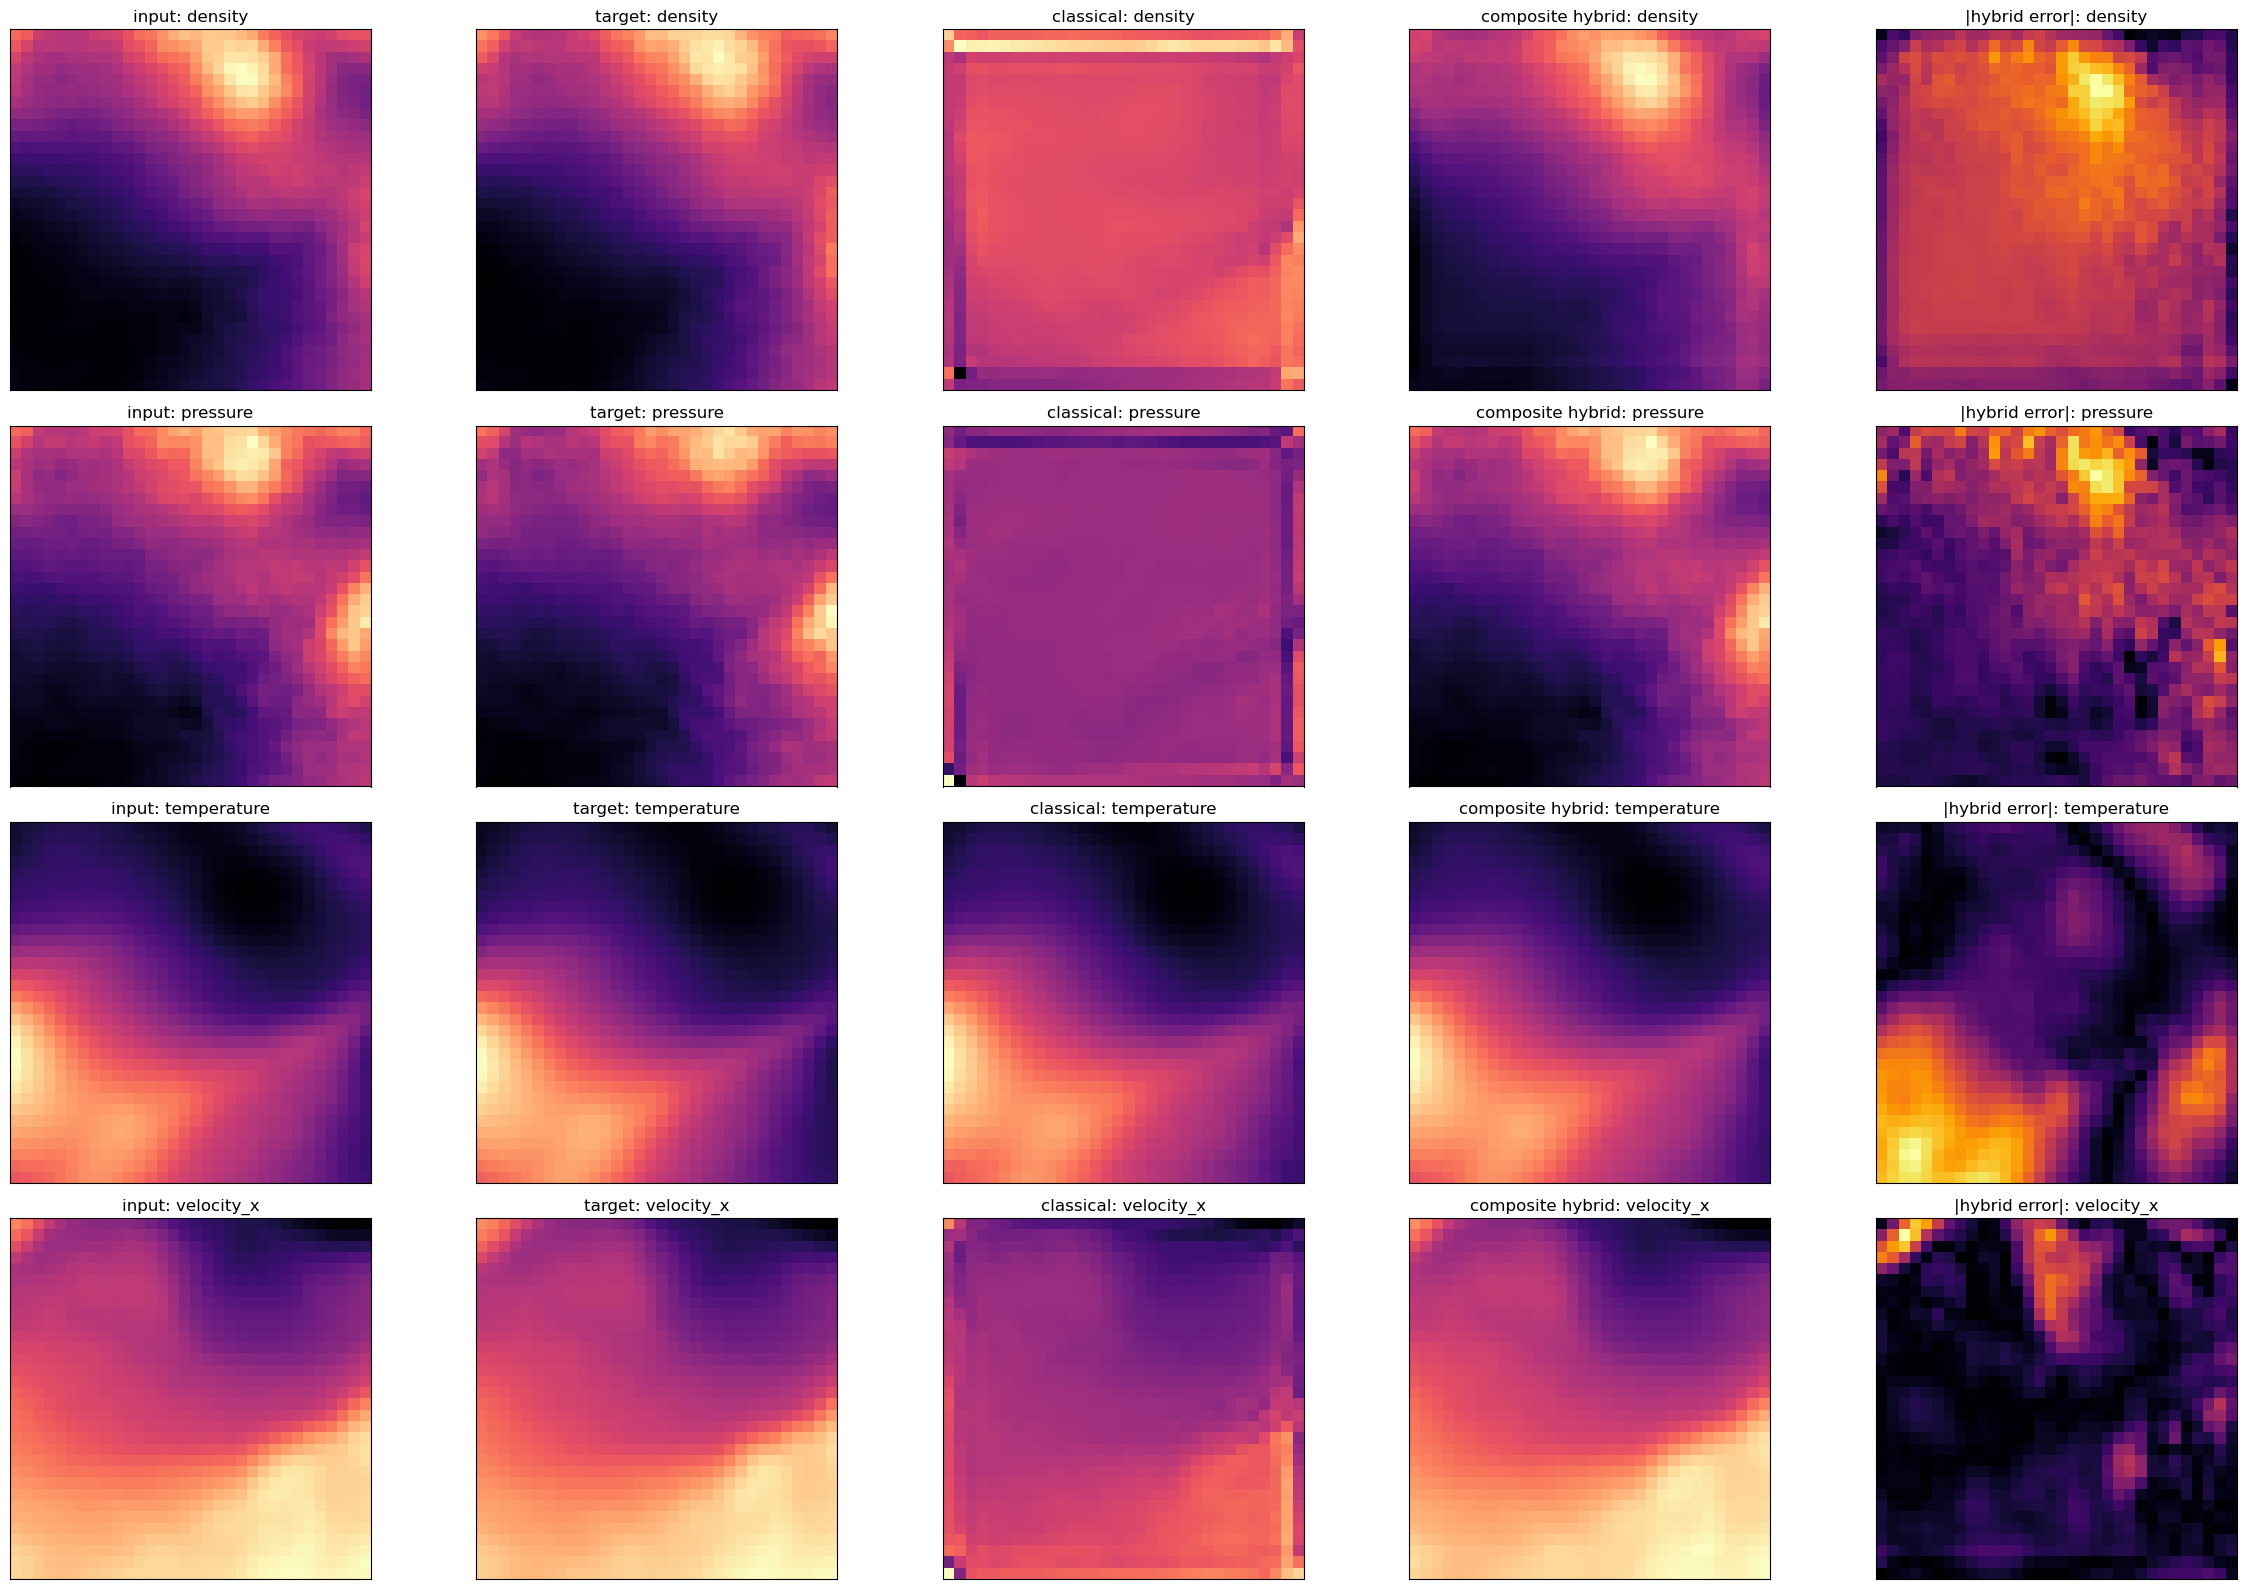

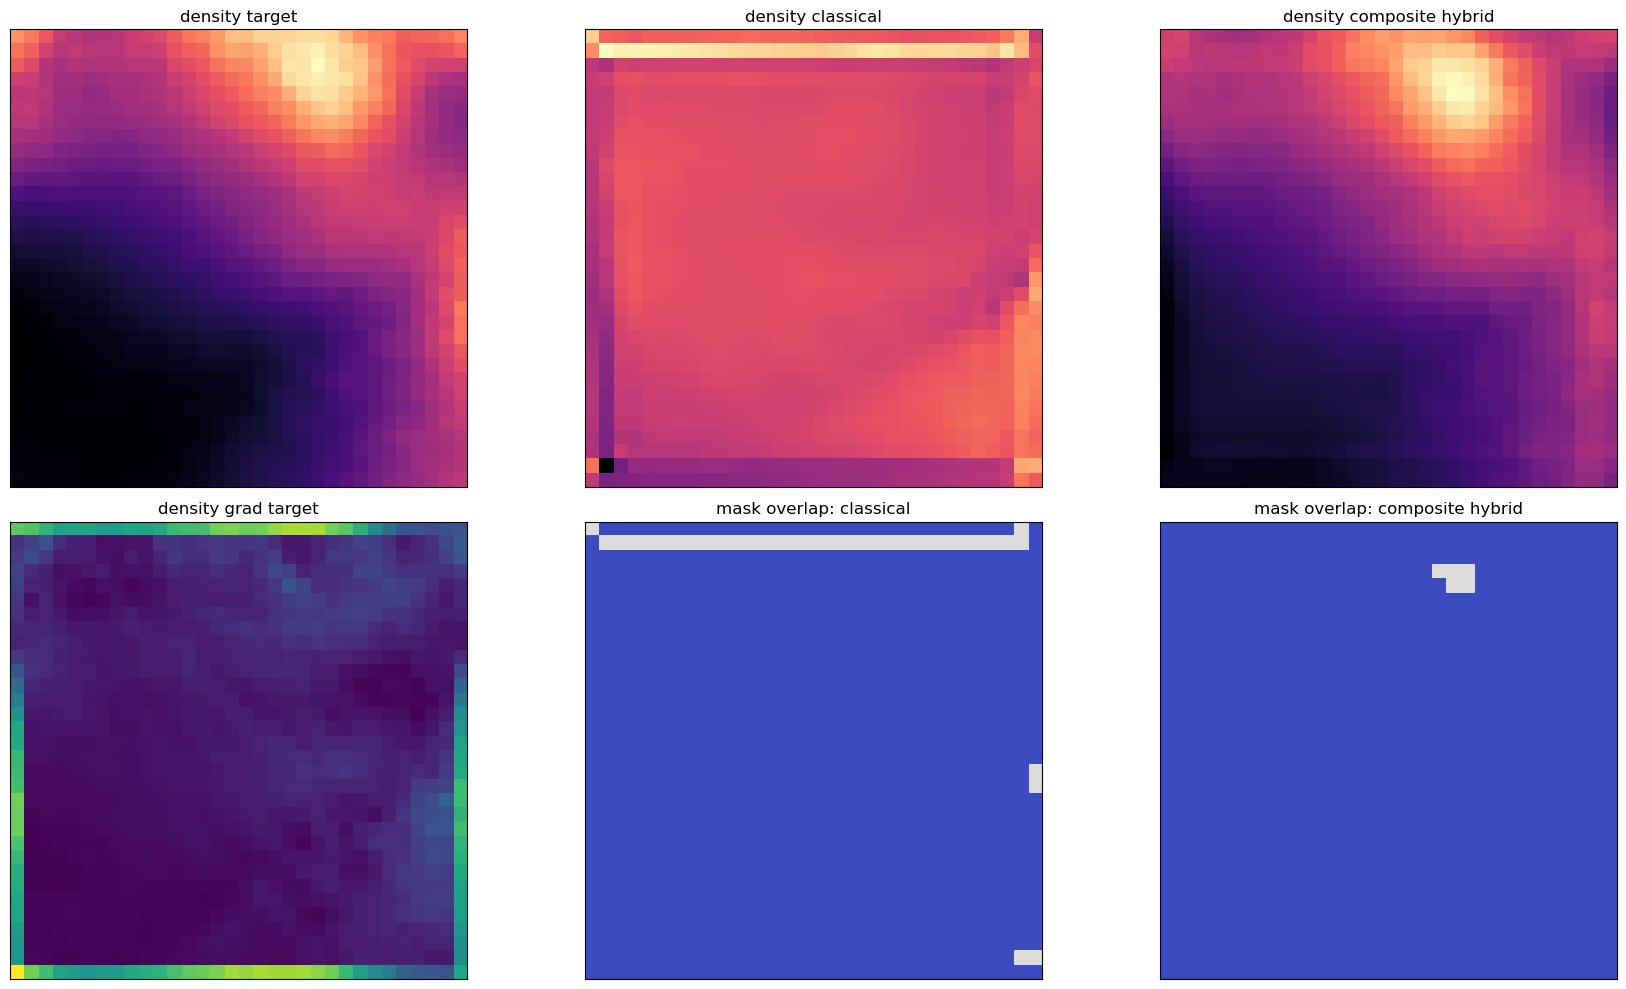

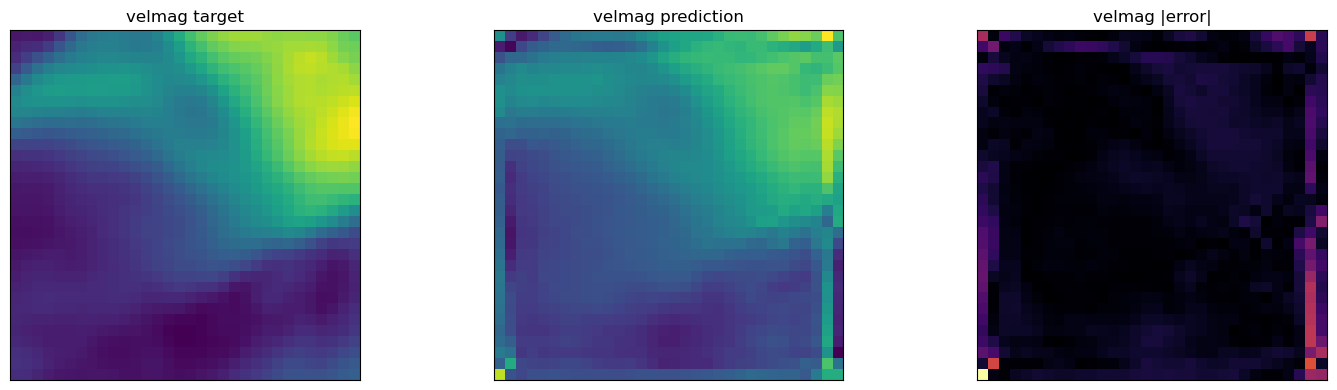

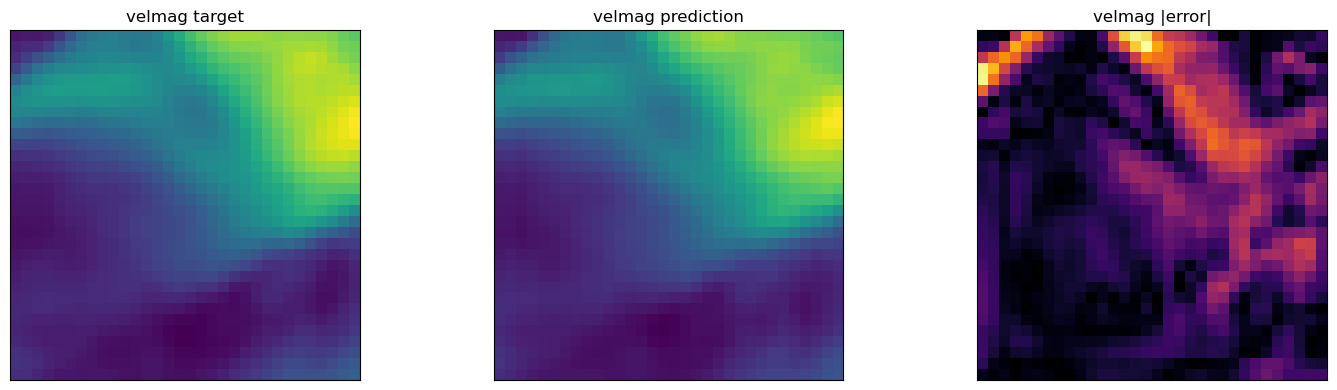

Displayed sample signature
{
  "rho0": 0.4449999928474426,
  "Z": 1.0,
  "T0": 1000.0,
  "input_time": 0.0,
  "output_time": 0.010204076766967773
}

Classical model metrics on displayed sample
{
  "mse_by_field": {
    "density": 0.6122457981109619,
    "pressure": 0.019572816789150238,
    "temperature": 197.58628845214844,
    "velocity_x": 0.023880936205387115,
    "velocity_y": 0.02067234180867672,
    "velocity_z": 0.011263594031333923
  },
  "rel_l2_by_field": {
    "density": 4.7589592933654785,
    "pressure": 3.068643808364868,
    "temperature": 0.03565847501158714,
    "velocity_x": 0.5043692588806152,
    "velocity_y": 0.4786839485168457,
    "velocity_z": 0.13371989130973816
  },
  "velocity_magnitude_rel_l2": 0.13715560734272003,
  "global_mse": 33.045654296875
}

Composite hybrid PINN metrics on displayed sample
{
  "mse_by_field": {
    "density": 0.002747937338426709,
    "pressure": 3.556072624633089e-05,
    "temperature": 161.06309509277344,
    "velocity_x": 0.0011

In [25]:
# [DROP-IN REPLACEMENT] — Classical vs composite hybrid PINN comparison
# -----------------------------------------------------------------------------
# PURPOSE
# Compare the current classical forecaster and the new composite hybrid PINN
# on the SAME sample.
# -----------------------------------------------------------------------------

@torch.no_grad()
def predict_classical_sample(model: nn.Module, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    y_hat = model(x)
    return y_hat.squeeze(0).cpu()

@torch.no_grad()
def predict_composite_hybrid_sample(model: nn.Module, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    constants = sample["constants"].unsqueeze(0).to(DEVICE)
    _, _, y_hat = model(x, constants)
    return y_hat.squeeze(0).cpu()

def plot_model_comparison_triplets(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
    fields: Optional[List[str]] = None,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (24, 16),
):
    if fields is None:
        fields = ["density", "pressure", "temperature", "velocity_x"]

    x = sample["x"].cpu()
    y = sample["y"].cpu()
    classical_pred = classical_pred.cpu()
    hybrid_pred = hybrid_pred.cpu()

    z_slice = x.shape[1] // 2 if z_slice is None else z_slice
    idxs = [FIELD_TO_INDEX[f] for f in fields]

    fig, axs = plt.subplots(len(fields), 5, figsize=figsize)

    if len(fields) == 1:
        axs = np.expand_dims(axs, axis=0)

    for r, (idx, name) in enumerate(zip(idxs, fields)):
        xin = x[idx, z_slice].numpy()
        ytrue = y[idx, z_slice].numpy()
        yclass = classical_pred[idx, z_slice].numpy()
        yhyb = hybrid_pred[idx, z_slice].numpy()
        err_hyb = np.abs(yhyb - ytrue)

        axs[r, 0].imshow(xin, cmap="magma")
        axs[r, 0].set_title(f"input: {name}")
        axs[r, 0].set_xticks([])
        axs[r, 0].set_yticks([])

        axs[r, 1].imshow(ytrue, cmap="magma")
        axs[r, 1].set_title(f"target: {name}")
        axs[r, 1].set_xticks([])
        axs[r, 1].set_yticks([])

        axs[r, 2].imshow(yclass, cmap="magma")
        axs[r, 2].set_title(f"classical: {name}")
        axs[r, 2].set_xticks([])
        axs[r, 2].set_yticks([])

        axs[r, 3].imshow(yhyb, cmap="magma")
        axs[r, 3].set_title(f"composite hybrid: {name}")
        axs[r, 3].set_xticks([])
        axs[r, 3].set_yticks([])

        axs[r, 4].imshow(err_hyb, cmap="inferno")
        axs[r, 4].set_title(f"|hybrid error|: {name}")
        axs[r, 4].set_xticks([])
        axs[r, 4].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_density_overlap_comparison(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
    dense_quantile: float = 0.95,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (18, 10),
):
    y = sample["y"].cpu()
    classical_pred = classical_pred.cpu()
    hybrid_pred = hybrid_pred.cpu()

    density_true = y[FIELD_TO_INDEX["density"]]
    density_classical = classical_pred[FIELD_TO_INDEX["density"]]
    density_hybrid = hybrid_pred[FIELD_TO_INDEX["density"]]

    z_slice = density_true.shape[0] // 2 if z_slice is None else z_slice

    mask_true = dense_region_mask_single(y, quantile=dense_quantile).float()
    mask_classical = dense_region_mask_single(classical_pred, quantile=dense_quantile).float()
    mask_hybrid = dense_region_mask_single(hybrid_pred, quantile=dense_quantile).float()

    grad_true = density_gradient_magnitude_4d(density_true)
    grad_classical = density_gradient_magnitude_4d(density_classical)
    grad_hybrid = density_gradient_magnitude_4d(density_hybrid)

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    axs[0, 0].imshow(density_true[z_slice].numpy(), cmap="magma")
    axs[0, 0].set_title("density target")
    axs[0, 0].set_xticks([])
    axs[0, 0].set_yticks([])

    axs[0, 1].imshow(density_classical[z_slice].numpy(), cmap="magma")
    axs[0, 1].set_title("density classical")
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])

    axs[0, 2].imshow(density_hybrid[z_slice].numpy(), cmap="magma")
    axs[0, 2].set_title("density composite hybrid")
    axs[0, 2].set_xticks([])
    axs[0, 2].set_yticks([])

    axs[1, 0].imshow(grad_true[z_slice].numpy(), cmap="viridis")
    axs[1, 0].set_title("density grad target")
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    overlap_classical = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_classical[z_slice].numpy()
    axs[1, 1].imshow(overlap_classical, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 1].set_title("mask overlap: classical")
    axs[1, 1].set_xticks([])
    axs[1, 1].set_yticks([])

    overlap_hybrid = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_hybrid[z_slice].numpy()
    axs[1, 2].imshow(overlap_hybrid, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 2].set_title("mask overlap: composite hybrid")
    axs[1, 2].set_xticks([])
    axs[1, 2].set_yticks([])

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def print_model_comparison_metrics(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
):
    y = sample["y"].unsqueeze(0).to(DEVICE)

    classical_metrics = evaluate_batch_metrics(
        classical_pred.unsqueeze(0).to(DEVICE),
        y,
    )
    hybrid_metrics = evaluate_batch_metrics(
        hybrid_pred.unsqueeze(0).to(DEVICE),
        y,
    )

    print("=" * 100)
    print("Displayed sample signature")
    print("=" * 100)
    print(json.dumps(sample_signature(sample), indent=2))

    print("\n" + "=" * 100)
    print("Classical model metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(classical_metrics, indent=2))

    print("\n" + "=" * 100)
    print("Composite hybrid PINN metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(hybrid_metrics, indent=2))

# -----------------------------------------------------------------------------
# Run comparison on the same sample
# -----------------------------------------------------------------------------
comparison_sample = sample0

classical_pred = predict_classical_sample(model, comparison_sample)
hybrid_pred = predict_composite_hybrid_sample(composite_hybrid_model, comparison_sample)

plot_model_comparison_triplets(
    comparison_sample,
    classical_pred,
    hybrid_pred,
    fields=["density", "pressure", "temperature", "velocity_x"],
)

plot_density_overlap_comparison(
    comparison_sample,
    classical_pred,
    hybrid_pred,
    dense_quantile=0.95,
)

plot_velocity_magnitude_diagnostics(
    comparison_sample["y"],
    classical_pred,
)

plot_velocity_magnitude_diagnostics(
    comparison_sample["y"],
    hybrid_pred,
)

print_model_comparison_metrics(
    comparison_sample,
    classical_pred,
    hybrid_pred,
)